In [2]:
# INIT ENVIRONMENT
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr, pearsonr
from matplotlib.patches import Rectangle
from pathlib import Path
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib as mpl
import pandas as pd
import numpy as np

# data source

URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"

def _read_owid_energy():
    # Read the OWID energy CSV into a DataFrame
    return pd.read_csv(URL, low_memory=False)

df = _read_owid_energy()
df.columns = df.columns.str.strip()
df_full = df.copy()

def _pick(df, primary, keywords):
    """Find the first matching column in the DataFrame by name or by keywords.
    
    Parameters:
    - df: DataFrame to search
    - primary: list of preferred exact column names (try these first)
    - keywords: list of keywords (or lists of alternative keywords) that must
                all be present in the column name (case-insensitive) to match
    
    Returns:
    - column name (string) from df.columns that matches criteria

    Raises:
    - KeyError if no matching column is found
    """
    # Try exact primary names first
    for c in primary:
        if c in df.columns:
            return c

    # Build a list of predicate functions based on keywords.
    # Each predicate returns True if the column name contains the required token(s).
    pats = []
    for kw in keywords:
        if isinstance(kw, (list, tuple)):
            # for a group of alternatives, match if any of them appear in the column name
            pats.append(lambda s, k=kw: any(x in s for x in k))
        else:
            pats.append(lambda s, k=kw: k in s)

    # Collect candidate columns that satisfy all predicates
    cands = []
    for c in df.columns:
        s = c.lower()
        if all(f(s) for f in pats):
            cands.append(c)

    # If multiple candidates, choose the shortest name (heuristic)
    if cands:
        return sorted(cands, key=len)[0]

    raise KeyError("not found: " + " / ".join(primary))

def ensure_gdp_per_capita(data, df_full):
    """Ensure the DataFrame has a 'gdp_per_capita' column.
    
    If 'gdp_per_capita' already exists and has non-missing values, return as-is.
    Otherwise, attempt to merge in GDP/ population columns from df_full and
    compute gdp_per_capita = gdp / population. If neither present nor derivable,
    raise KeyError.
    """
    if "gdp_per_capita" in data.columns and data["gdp_per_capita"].notna().any():
        return data

    # Pick available columns among country, year, gdp_per_capita, gdp, population
    cols = [c for c in ["country","year","gdp_per_capita","gdp","population"] if c in df_full.columns]
    # Merge to bring in potential source columns (suffix _src if overlapping)
    merged = data.merge(df_full[cols], on=["country","year"], how="left", suffixes=("","_src"))

    # If merged now has gdp_per_capita with values, return it
    if "gdp_per_capita" in merged.columns and merged["gdp_per_capita"].notna().any():
        return merged

    # If both gdp and population are available, compute gdp_per_capita
    if {"gdp","population"}.issubset(merged.columns):
        merged["gdp_per_capita"] = pd.to_numeric(merged["gdp"], errors="coerce") / \
                                   pd.to_numeric(merged["population"], errors="coerce")
        return merged

    # Otherwise can't derive GDP per capita
    raise KeyError("GDP per capita not available and not derivable")

# Keep only countries with 3-letter ISO codes (typical country rows in OWID)
countries = df[df["iso_code"].astype(str).str.len() == 3].copy()

# Auto-detect relevant source columns for different shares using _pick
renew_src = _pick(
    df,
    ["renewables_share_elec","renewables_electricity_share","renewables_share_of_electricity"],
    [["renew","green"], ["share"], ["elec","electric","electricity"]]
)
solar_src = _pick(
    df,
    ["solar_share_elec","solar_electricity_share","share_elec_solar"],
    [["solar"], ["share"], ["elec","electric","electricity"]]
)
wind_src = _pick(
    df,
    ["wind_share_elec","wind_electricity_share","share_elec_wind"],
    [["wind"], ["share"], ["elec","electric","electricity"]]
)
hydro_src = _pick(
    df,
    ["hydro_share_elec","hydro_electricity_share","share_elec_hydro"],
    [["hydro"], ["share"], ["elec","electric","electricity"]]
)
bio_src = _pick(
    df,
    ["biofuel_share_elec","biofuel_electricity_share","share_elec_biofuel","bioenergy_electricity_share"],
    [[("biofuel","bioenergy","bio")], ["share"], ["elec","electric","electricity"]]
)

# Select columns of interest if they exist in the country-level DataFrame
cols = ["country","year","gdp_per_capita", renew_src, solar_src, wind_src, hydro_src, bio_src]
data = countries[[c for c in cols if c in countries.columns]].copy()

# If iso_code wasn't included earlier, add it from the full dataset
if "iso_code" not in data.columns and "iso_code" in df.columns:
    data = data.merge(df[["country","iso_code"]].drop_duplicates(), on="country", how="left")

# Normalize detected source column names to the standard names used later in the notebook
name_map = {
    renew_src: "renewables_share_elec",
    solar_src: "solar_share_elec",
    wind_src:  "wind_share_elec",
    hydro_src: "hydro_share_elec",
    bio_src:   "biofuel_share_elec",
}
data = data.rename(columns=name_map)

# Ensure gdp_per_capita is present (or derivable)
data = ensure_gdp_per_capita(data, df_full)


# init

PALETTE = {
    "green": "#5B6E4D",
    "green_light": "#9FB27C",
    "green_dark": "#2F4F1E",
    "orange": "#C88C4A",
    "orange_dark": "#8D6128",
    "neutral": "#4D4D4D",
    "grid": "#D9D9D9",
    "highlight": "#EFF3EA",
}

STACK_COLORS = {
    "Hydro":   "#8FA8C6",
    "Wind":    "#97C4BF",
    "Solar":   "#E9B06E",
    "Biofuel": "#8FB784",
    "Other":   "#BFBFBF",
}

mpl.rcParams.update({
    "figure.figsize": (9, 5.2),
    "figure.dpi": 140,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titlepad": 10,
    "axes.labelcolor": PALETTE["neutral"],
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "xtick.color": PALETTE["neutral"],
    "ytick.color": PALETTE["neutral"],
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.frameon": False,
    "legend.fontsize": 10.5,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "savefig.bbox": "tight",
    "savefig.dpi": 140,
    "font.family": "DejaVu Sans",
    "axes.prop_cycle": mpl.cycler(color=[
        "#566573", "#6C8EBF", "#8FB784", "#C2B280", "#97C4BF", "#A7A7A7", "#C88C4A"
    ]),
})

# functions

def export(fig, name, folder="figures"):
    Path(folder).mkdir(parents=True, exist_ok=True)
    path = f"{folder}/{name}.png"
    fig.savefig(path)
    print(f"Saved: {path}")

def add_source(fig, text):
    fig.text(0.01, 0.01, text, ha="left", va="bottom", fontsize=9, color=PALETTE["neutral"])

def style_legend_below(fig, ax, ncol=3):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=ncol, frameon=False, handlelength=2.0)
    fig.subplots_adjust(bottom=0.22)

def policy_band(ax, x0, x1, label=None):
    y0, y1 = ax.get_ylim()
    ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, color=PALETTE["highlight"], zorder=-1))
    if label:
        ax.text((x0+x1)/2, 1.01, label, transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=10, color=PALETTE["neutral"])

SERIES_ORDER = [
    PALETTE["green"],
    PALETTE["orange"],
    PALETTE["green_light"],
    "#6C8EBF",
    "#8C8C8C",
]

def series_color(i: int) -> str:
    return SERIES_ORDER[i % len(SERIES_ORDER)]

CMAP_SEQ_GREEN = LinearSegmentedColormap.from_list(
    "seq_green", ["#F5FAEC", PALETTE["green_light"], PALETTE["green_dark"]], N=256
)

CMAP_DIV_BALANCE = LinearSegmentedColormap.from_list(
    "div_balance", [PALETTE["orange_dark"], "#F3F5EE", PALETTE["green_dark"]], N=256
)



In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

def generate_fast_regression_future(df, years_future=50, cols_to_predict=None,
                                   max_degree=4):
    """
    Generate synthetic future data using polynomial regression with automatic
    degree selection via AIC and realistic noise. Also enforces consistency
    among renewable component shares.
    Parameters:
    - df: DataFrame with historical data (must contain 'country' and 'year' columns)
    - years_future: number of future years to generate
    - cols_to_predict: list of column names to forecast
    - max_degree: maximum polynomial degree to consider for fitting
    Returns:
    - DataFrame extended with future years and predicted columns
    """

    if cols_to_predict is None:
        raise ValueError("You must provide a list of columns to predict.")

    results = []

    # Process each country separately because the evolution of each series
    # is independent and should not be influenced by other countries.
    for country, g in df.groupby("country"):

        g = g.sort_values("year").copy()

        last_year = g["year"].max()
        future_years = np.arange(last_year + 1, last_year + years_future + 1).reshape(-1, 1)

        # Base fields for the output rows before adding predictions.
        base = {
            "year": future_years.flatten(),
            "country": country,
            "iso_code": g["iso_code"].iloc[-1] if "iso_code" in g.columns else np.nan
        }

        future_cols = {}

        # Each column is forecasted independently using the same procedure.
        for col in cols_to_predict:

            if col not in g.columns:
                continue

            y = g[col].astype(float).values
            x = g["year"].values.reshape(-1, 1)

            # Missing values are filled to avoid regression failures.
            y = pd.Series(y).ffill().bfill().values
            if np.isnan(y).all():
                continue

            mask = ~np.isnan(y)
            x_fit, y_fit = x[mask], y[mask]

            # A polynomial model requires at least 3 points.
            if len(y_fit) < 3:
                continue

            # Polynomial degree is selected automatically using AIC
            # AIC is a trade-off between goodness of fit and model complexity.
            best_pred = None
            best_aic = np.inf

            for deg in range(1, max_degree + 1):
                try:
                    # Fit polynomial regression of degree 'deg'
                    poly = PolynomialFeatures(degree=deg)
                    # Transform input features to polynomial features
                    Xp = poly.fit_transform(x_fit)
                    # Fit linear regression on transformed features
                    model = LinearRegression().fit(Xp, y_fit)
                    # Make predictions on the training data
                    pred_fit = model.predict(Xp)
                    # Compute residuals and variance
                    resid = y_fit - pred_fit
                    variance = np.var(resid)
                    # AIC penalizes overly complex models while rewarding good fit.
                    k = Xp.shape[1]
                    aic = len(y_fit) * np.log(variance + 1e-9) + 2 * k
                    # Select the model with the lowest AIC
                    if aic < best_aic:
                        best_aic = aic
                        best_pred = model.predict(poly.transform(future_years))
                        best_poly = poly
                        best_model = model

                except Exception:
                    pass

            # If all polynomial fits failed, fall back to a constant projection.
            if best_pred is None:
                best_pred = np.full(years_future, y_fit[-1])

            # Noise is proportional to the historical standard deviation
            # to preserve the characteristic variability of each country-series.
            noise_scale = np.std(y_fit)
            noise = np.random.normal(0, noise_scale, years_future)

            future_cols[col] = best_pred + noise

        # Build the future dataframe by combining all predictions.
        df_future = pd.DataFrame({**base, **future_cols})

        # Columns not predicted for this country are set to NaN for consistency.
        for col in df.columns:
            if col not in df_future.columns:
                df_future[col] = np.nan

        # Renewable component shares must remain coherent.
        # Components cannot be negative, and their sum cannot exceed the total share.
        comp_cols = [
            "hydro_share_elec",
            "wind_share_elec",
            "solar_share_elec",
            "biofuel_share_elec",
        ]
        comp_cols = [c for c in comp_cols if c in df_future.columns]

        if comp_cols and "renewables_share_elec" in df_future.columns:

            # Components cannot drop below zero.
            for c in comp_cols:
                df_future[c] = df_future[c].clip(lower=0)

            # The total renewable share is capped between 0 and 100.
            df_future["renewables_share_elec"] = df_future["renewables_share_elec"].clip(0, 100)

            # If the sum of components exceeds the total, the components are
            # rescaled proportionally to match the renewable total.
            sum_components = df_future[comp_cols].sum(axis=1)
            mask_excess = sum_components > df_future["renewables_share_elec"]

            df_future.loc[mask_excess, comp_cols] = (
                df_future.loc[mask_excess, comp_cols]
                .div(sum_components[mask_excess], axis=0)
                .mul(df_future.loc[mask_excess, "renewables_share_elec"], axis=0)
            )

        results.append(df_future)

    if results:
        return pd.concat([df] + results, ignore_index=True)
    else:
        return df.copy()
    
feature_cols = [
    "gdp",
    "renewables_share_elec",
    "solar_share_elec",
    "wind_share_elec",
    "hydro_share_elec",
    "biofuel_share_elec",
]

data = generate_fast_regression_future(df, years_future=26, cols_to_predict=feature_cols, max_degree=5)


/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/4118498947.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_future[col] = np.nan
/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/4118498947.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_future[col] = np.nan
/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/4118498947.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

Saved: figures/features_with_forecast.png


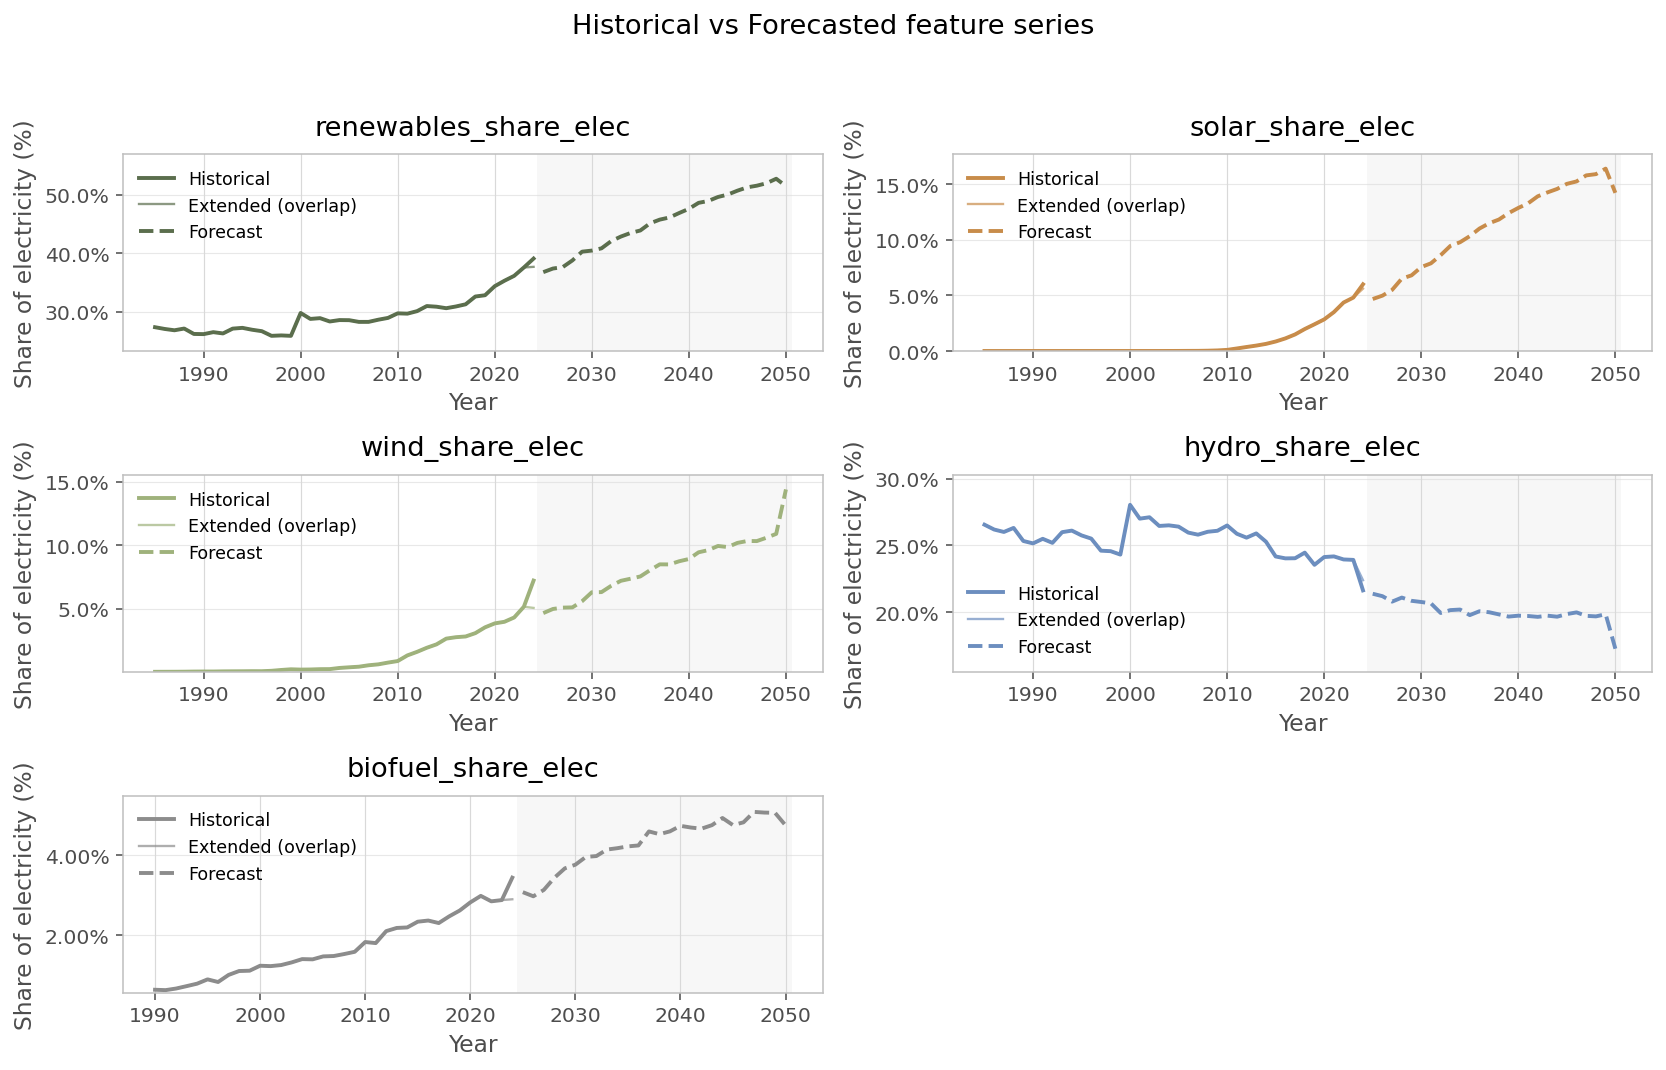

In [5]:
# Show historical vs forecasted feature series
def plot_features_with_forecast(df_hist, df_ext, features, agg="mean", save=False, out_name="features_with_forecast"):
    """
    Plot aggregated time series for each feature from historical df (df_hist)
    and the extended dataframe (df_ext) which contains forecasted years.
    Parameters:
    - df_hist: DataFrame with historical data (must contain 'year' column)
    - df_ext: DataFrame with extended data including forecasted years (must contain 'year' column)
    - features: list of column names to plot
    - agg: aggregation to apply per year ("mean" or "median")
    - save: whether to save the figure
    - out_name: filename to use when saving the figure
    Returns:
    - fig, axes
    """
    feats = [c for c in features if c in df_hist.columns or c in df_ext.columns]
    if not feats:
        raise ValueError("No feature columns available to plot")

    n = len(feats)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), squeeze=False)
    axes = axes.flatten()

    # determine last historical year from df_hist
    last_hist_year = int(df_hist["year"].max())

    for i, feat in enumerate(feats):
        ax = axes[i]
        # yearly aggregation helpers
        if feat in df_hist.columns:
            g_hist = getattr(df_hist.groupby("year")[feat], agg)().reset_index()
        else:
            g_hist = pd.DataFrame(columns=["year", feat])

        if feat in df_ext.columns:
            g_ext = getattr(df_ext.groupby("year")[feat], agg)().reset_index()
        else:
            g_ext = pd.DataFrame(columns=["year", feat])

        # convert proportions (0..1) to percentages if needed
        max_hist = g_hist[feat].max() if not g_hist.empty else 0
        max_ext = g_ext[feat].max() if not g_ext.empty else 0
        need_pct = max(max_hist, max_ext) <= 1.5

        if need_pct:
            g_hist[feat] = g_hist[feat] * 100
            g_ext[feat] = g_ext[feat] * 100

        col = series_color(i)
        # plot historical (solid)
        if not g_hist.empty:
            ax.plot(g_hist["year"], g_hist[feat], color=col, lw=2.0, label="Historical")
        # plot extended (solid for overlap, dashed for forecast region)
        if not g_ext.empty:
            # overlap part
            overlap = g_ext[g_ext["year"] <= last_hist_year]
            future = g_ext[g_ext["year"] > last_hist_year]
            if not overlap.empty:
                ax.plot(overlap["year"], overlap[feat], color=col, lw=1.2, alpha=0.7, label="Extended (overlap)")
            if not future.empty:
                ax.plot(future["year"], future[feat], color=col, lw=2.0, ls="--", label="Forecast")
                # lightly shade forecast area
                ax.axvspan(future["year"].min() - 0.5, future["year"].max() + 0.5, color="#F7F7F7", zorder=-1)

        ax.set_title(feat)
        ax.set_xlabel("Year")
        ax.set_ylabel("Share of electricity (%)")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
        ax.grid(axis="y", color=PALETTE["grid"], lw=0.6, alpha=0.6)
        ax.legend(frameon=False, fontsize=9)
        # tidy limits
        all_y = pd.concat([g_hist[feat] if feat in g_hist else pd.Series(dtype=float),
                           g_ext[feat] if feat in g_ext else pd.Series(dtype=float)])
        if not all_y.empty:
            ax.set_ylim(bottom=max(0, all_y.min() * 0.9), top=min(100, all_y.max() * 1.08))

    # remove unused axes
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Historical vs Forecasted feature series", fontsize=14, y=0.98)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save:
        export(fig, out_name)

    plt.show()
    return fig, axes

feature_cols = [
    "renewables_share_elec",
    "solar_share_elec",
    "wind_share_elec",
    "hydro_share_elec",
    "biofuel_share_elec",
]

# call the new plotting helper
fig, axes = plot_features_with_forecast(df, data, feature_cols, save=True, out_name="features_with_forecast")

Saved: figures/01_world_trend_iqr_centered.png


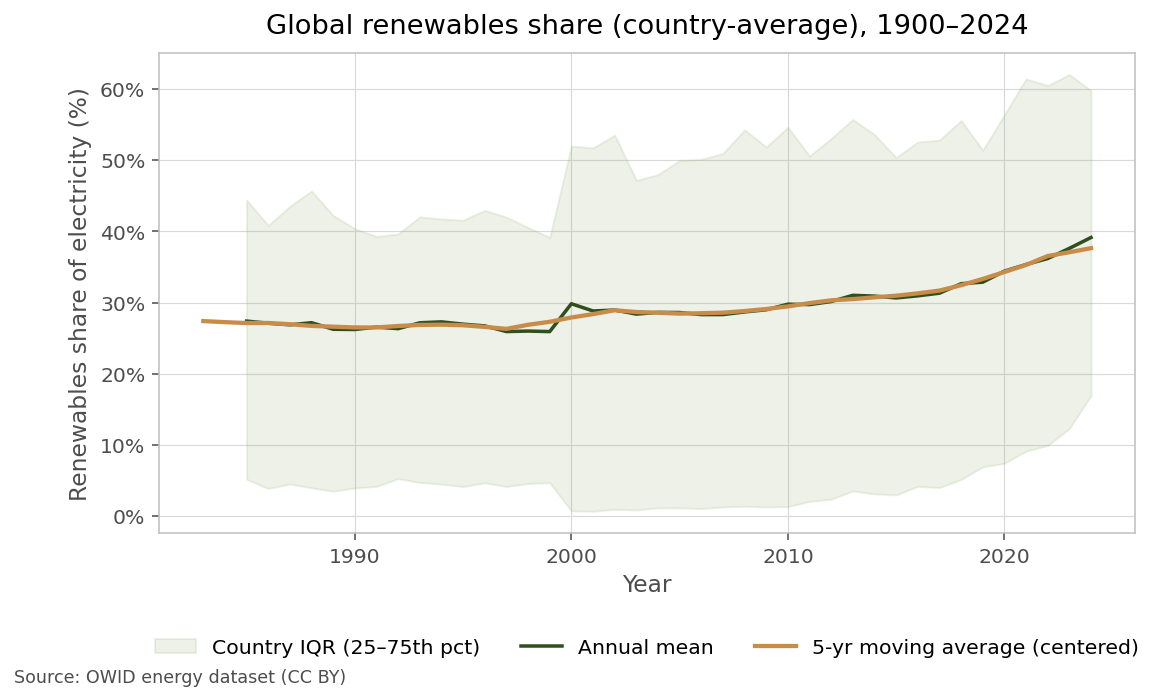

Saved: figures/01_world_trend_iqr_centered_forecasted.png


/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/604255464.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


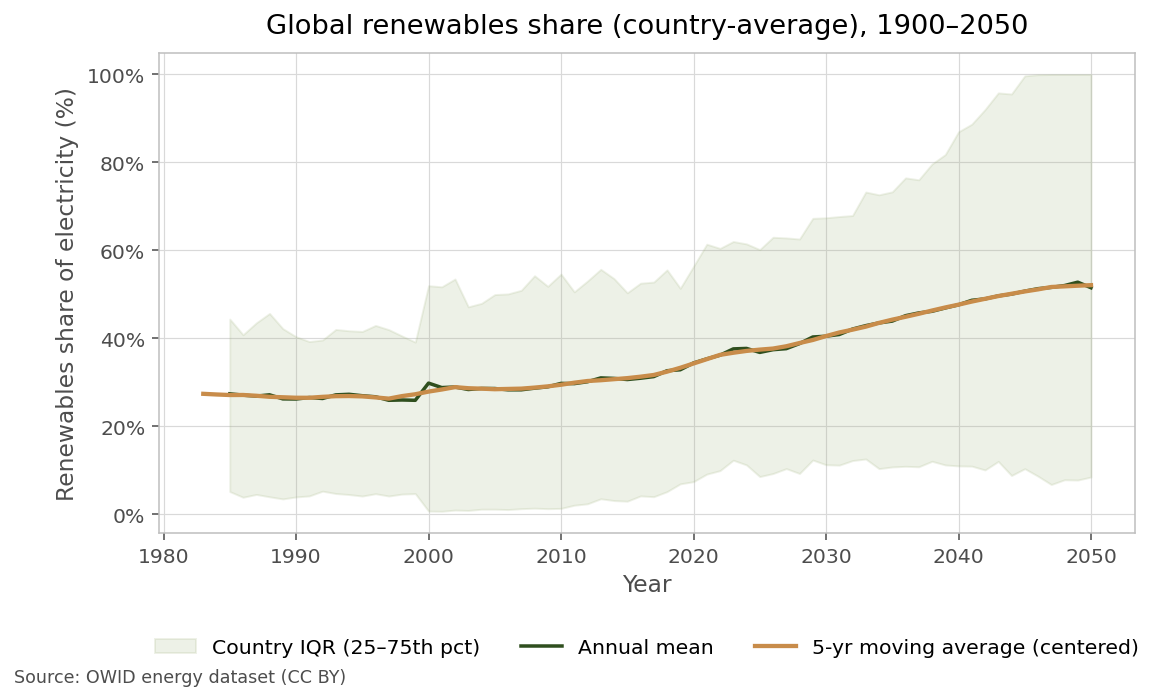

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/604255464.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [6]:
# world trend plot with IQR and centered moving average
def plot_world_trend_iqr_centered(data=data, col="renewables_share_elec", save=True, ma_window=5, out_name="01_world_trend_iqr_centered"):
        """
        Plot global country-average of `col` by year with IQR band (25–75th pct)
        and a centered moving average.

        Parameters:
        - data: DataFrame with columns ["country","year", col]
        - col: column name to plot (default renewables_share_elec)
        - save: whether to export the figure using `export(...)`
        - ma_window: window size for centered moving average (default 5)
        - out_name: filename base used when saving
        Returns:
        - fig, ax
        """
        # aggregate per-year: mean and IQR
        g = data.groupby("year")[col]
        annual = g.mean().rename("mean").to_frame()
        annual["q25"] = g.quantile(0.25)
        annual["q75"] = g.quantile(0.75)
        annual = annual.reset_index()

        # centered moving average of the annual mean
        annual[f"ma{ma_window}"] = annual["mean"].rolling(ma_window, center=True, min_periods=1).mean()

        # --- plotting ---
        fig, ax = plt.subplots()
        ax.fill_between(
                annual["year"], annual["q25"], annual["q75"],
                color=PALETTE["green_light"], alpha=0.18,
                label="Country IQR (25–75th pct)"
        )

        ax.plot(annual["year"], annual["mean"],
                        color=PALETTE["green_dark"], lw=1.8, label="Annual mean")

        ax.plot(annual["year"], annual[f"ma{ma_window}"],
                        color=PALETTE["orange"], lw=2.2, label=f"{ma_window}-yr moving average (centered)")

        ax.set_xlabel("Year")
        ax.set_ylabel("Renewables share of electricity (%)")
        ax.set_title(f"Global renewables share (country-average), {int(annual.year.min())}–{int(annual.year.max())}")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

        style_legend_below(fig, ax, ncol=3)
        add_source(fig, "Source: OWID energy dataset (CC BY)")

        if save:
                export(fig, out_name)

        plt.show()
        return fig, ax

# Plot the world with only real data
fig, ax = plot_world_trend_iqr_centered(data=df, save=True)
fig.show()

# Plot the world with forecasted data
fig, ax = plot_world_trend_iqr_centered(data=data, save=True, out_name="01_world_trend_iqr_centered_forecasted")
fig.show()


Saved: figures/02_top15_renewables_breakdown.png


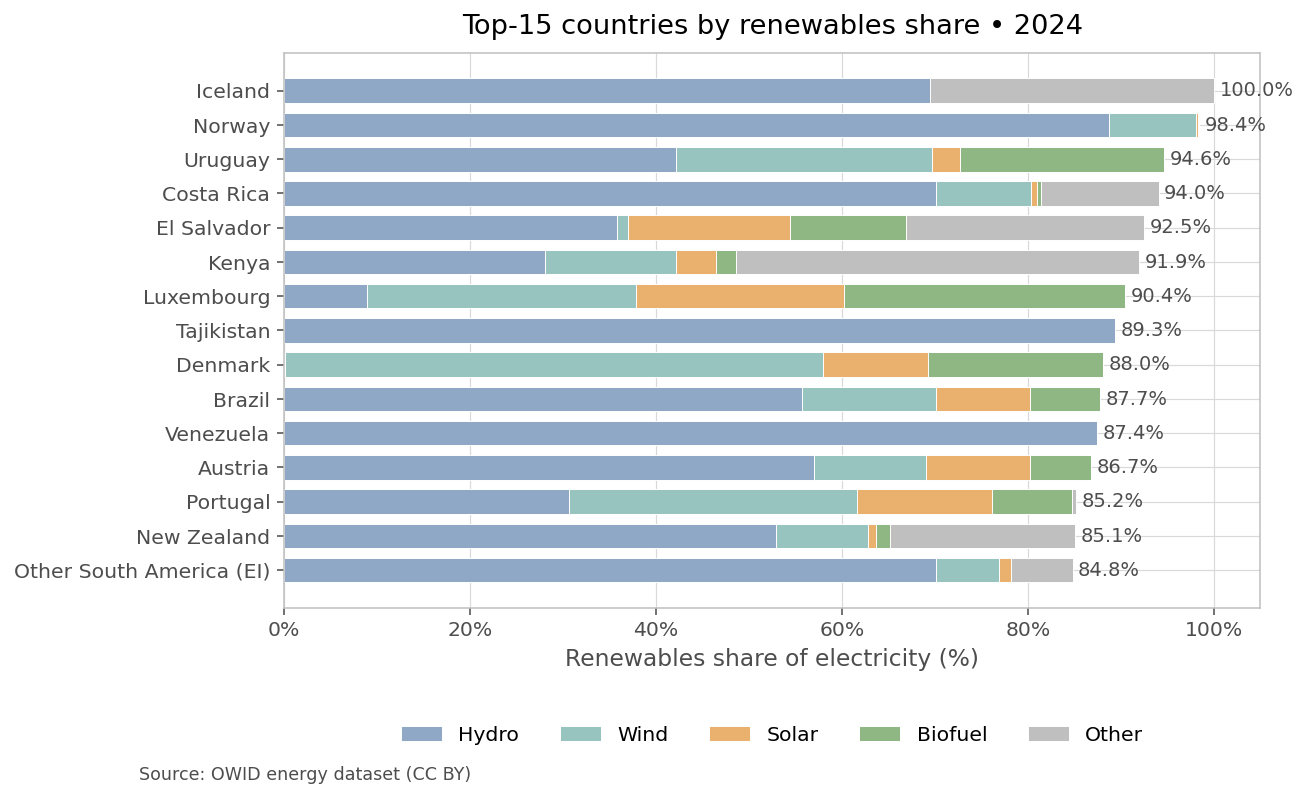

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/646702625.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: figures/02_top15_renewables_breakdown_forecasted.png


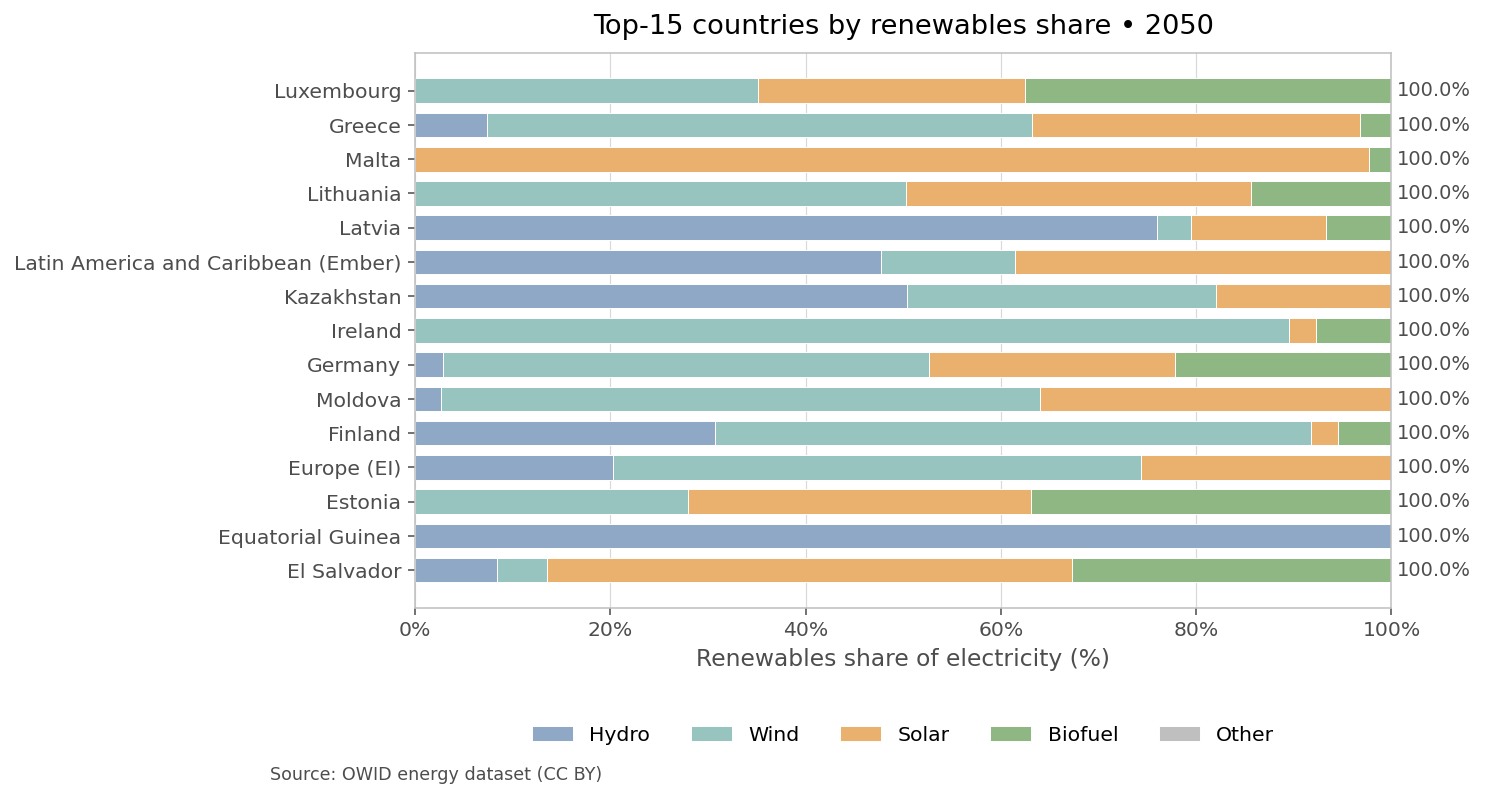

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/646702625.py:107: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [7]:
# stacked bar breakdown for top-15 renewables
def plot_top15_renewables_breakdown(data=data, latest_year=None, save=True, out_name="02_top15_renewables_breakdown"):
    """Plot a horizontal stacked-bar breakdown of renewables for the top-15 countries by renewables share.

    Parameters:
        data (DataFrame): DataFrame containing country-level data with columns for renewables shares.
        latest_year (int, optional): Year to consider for ranking countries. If None, uses the latest year in the data.
        save (bool): Whether to save the figure using `export(...)`.
        out_name (str): Filename base used when saving.
    Returns:
        tuple: (fig, ax) matplotlib Figure and Axes for the created plot.
    """
    # choose columns that actually exist in the provided dataframe
    cols = ["country", "year", "renewables_share_elec", "hydro_share_elec", "wind_share_elec", "solar_share_elec", "biofuel_share_elec"]
    cols = [c for c in cols if c in data.columns]
    df_parts = data[cols].copy()

    # component columns we will stack (only those present)
    comp_cols = [c for c in ["hydro_share_elec", "wind_share_elec", "solar_share_elec", "biofuel_share_elec"] if c in df_parts.columns]

    # fill missing component shares with 0 and ensure non-negative
    for c in comp_cols:
        df_parts[c] = df_parts[c].fillna(0).clip(lower=0)

    # compute residual "other" share if renewables total is available, otherwise set to 0
    if "renewables_share_elec" in df_parts.columns:
        df_parts["other_share_elec"] = (df_parts["renewables_share_elec"] - df_parts[comp_cols].sum(axis=1)).clip(lower=0)
    else:
        df_parts["other_share_elec"] = 0.0

    # determine latest year if not provided
    latest_year = int(df_parts["year"].max()) if latest_year is None else int(latest_year)

    # select top-15 by total renewables (or by sum of components if total missing)
    if "renewables_share_elec" in df_parts.columns:
        top = (
            df_parts[df_parts["year"] == latest_year]
            .dropna(subset=["renewables_share_elec"])
            .sort_values("renewables_share_elec", ascending=False)
            .head(15)
            .set_index("country")
        )
    else:
        # fallback: rank by sum of component shares
        df_parts["_total_parts"] = df_parts[comp_cols].sum(axis=1)
        top = (
            df_parts[df_parts["year"] == latest_year]
            .sort_values("_total_parts", ascending=False)
            .head(15)
            .set_index("country")
        )

    # final stack order restricted to available columns
    stack_order = [c for c in ["hydro_share_elec", "wind_share_elec", "solar_share_elec", "biofuel_share_elec", "other_share_elec"] if c in top.columns]
    # map component column -> display label
    label_map = {
        "hydro_share_elec": "Hydro",
        "wind_share_elec":  "Wind",
        "solar_share_elec": "Solar",
        "biofuel_share_elec":"Biofuel",
        "other_share_elec": "Other",
    }
    labels = [label_map[c] for c in stack_order]

    # plotting
    fig, ax = plt.subplots(figsize=(9, 6))
    y = np.arange(len(top))
    left = np.zeros(len(top))

    for key in stack_order:
        vals = top[key].values
        lab = label_map[key]
        # get color from STACK_COLORS (assumes keys like "Hydro","Wind"... exist)
        color = STACK_COLORS.get(lab, "#BFBFBF")
        ax.barh(y, vals, left=left, color=color, edgecolor="white", height=0.72, label=lab, linewidth=0.5)
        left = left + vals

    # annotate totals if available
    if "renewables_share_elec" in top.columns:
        for i, (ctry, row) in enumerate(top.iterrows()):
            ax.text(row["renewables_share_elec"] + 0.6, i, f'{row["renewables_share_elec"]:.1f}%',
                    va="center", ha="left", fontsize=10, color=PALETTE["neutral"])

    ax.set_yticks(y)
    ax.set_yticklabels(top.index)
    ax.invert_yaxis()
    ax.set_xlabel("Renewables share of electricity (%)")
    ax.set_title(f"Top-15 countries by renewables share • {latest_year}")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    # legend, source and export
    style_legend_below(fig, ax, ncol=len(labels))
    add_source(fig, "Source: OWID energy dataset (CC BY)")

    if save:
        export(fig, out_name)

    plt.show()
    return fig, ax

# Plot the top-15 renewables breakdown with only historical data
fig, ax = plot_top15_renewables_breakdown(data=df, save=True)
fig.show()

# Plot the top-15 renewables breakdown with forecasted data
fig, ax = plot_top15_renewables_breakdown(data=data, save=True, out_name="02_top15_renewables_breakdown_forecasted")
fig.show()

Saved: figures/02b_dumbbell_top15_growth.png


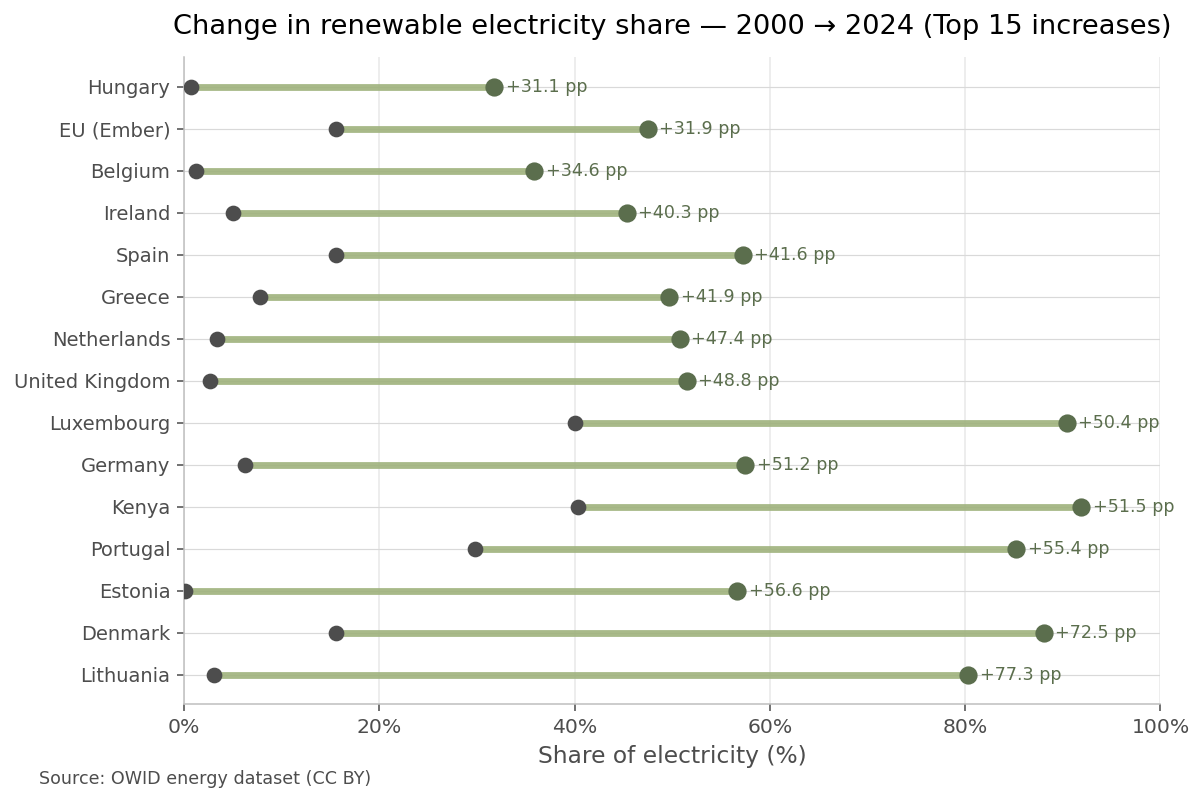

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/170052834.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: figures/02b_dumbbell_top15_growth_forecasted.png


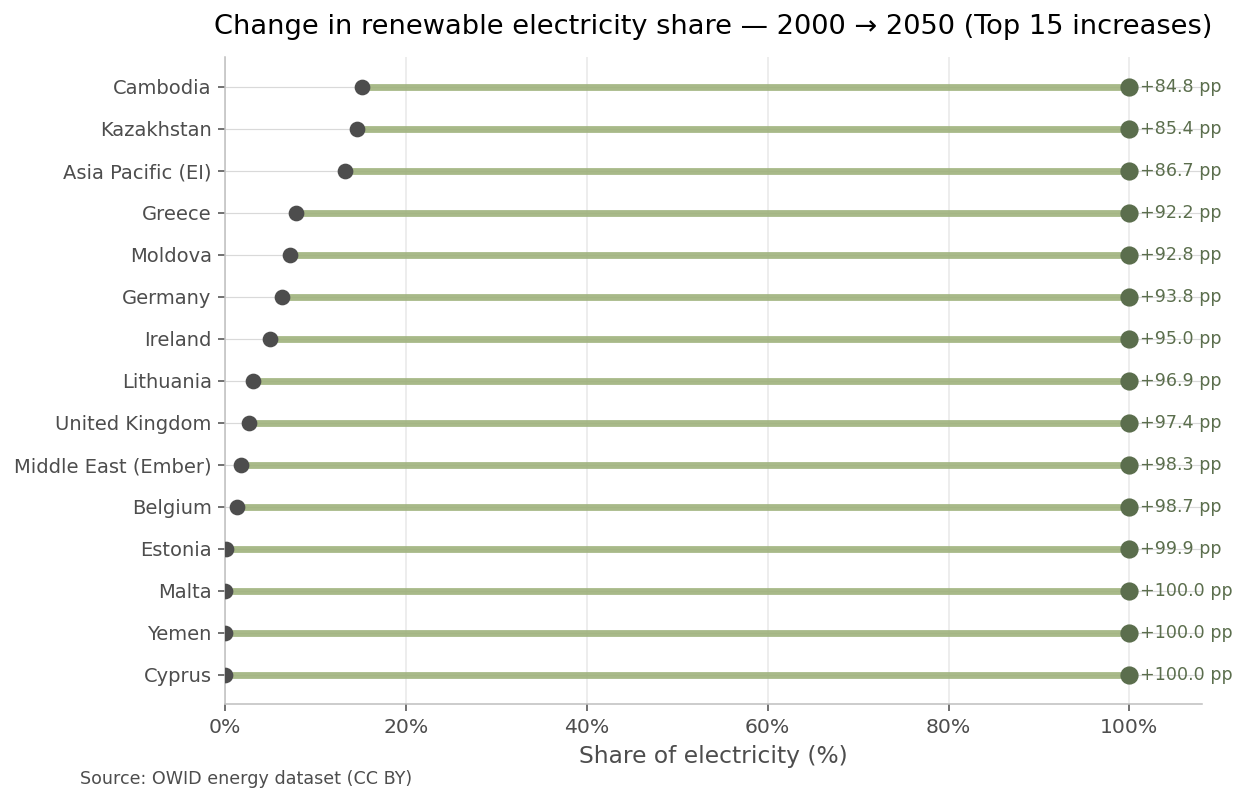

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/170052834.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [8]:
# dumbbell plot for top-15 growth in renewables share
def plot_dumbbell_top15_growth(data,
                              renew="renewables_share_elec",
                              base_year=None,
                              last_year=None,
                              top_n=15,
                              out_name="02b_dumbbell_top15_growth",
                              save=True,
                              figsize=(9, 6)):
    """
    Draw a dumbbell plot for the top-N countries by change in `renew` between
    `base_year` and `last_year`.

    Parameters
    - data: DataFrame with at least ["country","year", renew]
    - renew: column name for renewables share (percent, 0..100)
    - base_year: if None, use 2000 when available else data.year.min()
    - last_year: if None, use data.year.max()
    - top_n: number of top increasers to show
    - out_name: filename base for export(...)
    - save: whether to call export(...)
    - figsize: figure size tuple
    Returns:
    - (fig, ax)
    """
    # determine years
    base_year = (2000 if (data["year"] >= 2000).any() else int(data["year"].min())) if base_year is None else int(base_year)
    last_year = int(data["year"].max()) if last_year is None else int(last_year)

    # select rows for the two years and pivot to get one row per country
    T = data.loc[data["year"].isin([base_year, last_year]), ["country", "year", renew]].dropna()
    P = T.pivot(index="country", columns="year", values=renew).dropna()

    # compute change and pick top increasers
    P["delta"] = P[last_year] - P[base_year]
    top = P.sort_values("delta", ascending=False).head(top_n).iloc[::-1]  # reversed so largest increase at top

    # plotting
    fig, ax = plt.subplots(figsize=figsize)
    for i, (ctry, row) in enumerate(top.iterrows()):
        y = i
        x0, x1 = row[base_year], row[last_year]
        # color line depending on growth sign
        line_color = PALETTE["green_light"] if row["delta"] > 0 else "#B5B5B5"
        end_color = PALETTE["green"] if row["delta"] > 0 else "#888888"

        # draw connecting line and endpoints
        ax.plot([x0, x1], [y, y], color=line_color, lw=3.5, alpha=0.9)
        ax.scatter(x0, y, s=50, color=PALETTE["neutral"], zorder=3)
        ax.scatter(x1, y, s=70, color=end_color, zorder=4)

        # annotate change in percentage points
        ax.text(x1 + 1.2, y, f"{row['delta']:+.1f} pp",
                va="center", ha="left",
                color=end_color, fontsize=9)

    # axis formatting
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=10)
    ax.set_xlabel("Share of electricity (%)")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.set_xlim(0, max(100, top[last_year].max() * 1.08))
    ax.invert_yaxis()

    ax.set_title(f"Change in renewable electricity share — {base_year} → {last_year} (Top {top_n} increases)", pad=12)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="x", color=PALETTE["grid"], lw=0.8, alpha=0.6)
    ax.set_axisbelow(True)

    add_source(fig, "Source: OWID energy dataset (CC BY)")
    if save:
        export(fig, out_name)

    plt.show()
    return fig, ax

# Plot dumbbell for top-15 growth with only historical data
fig, ax = plot_dumbbell_top15_growth(data=df, save=True)
fig.show()

# Plot dumbbell for top-15 growth with forecasted data
fig, ax = plot_dumbbell_top15_growth(data=data, save=True, out_name="02b_dumbbell_top15_growth_forecasted")
fig.show()


Saved: figures/02c_table_risers_fallers_final.png


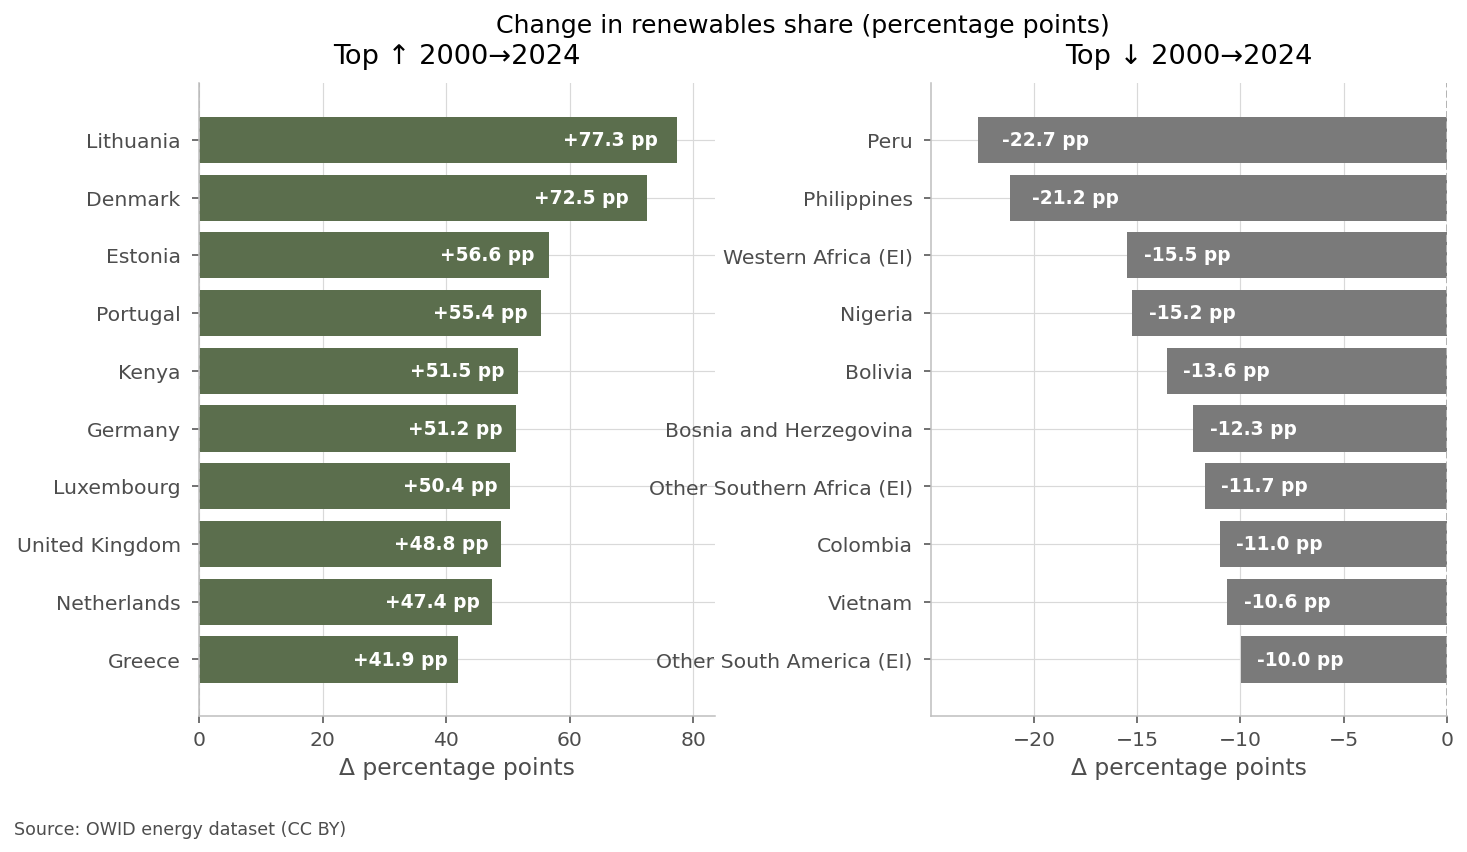

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/2469035852.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: figures/02c_table_risers_fallers_forecasted.png


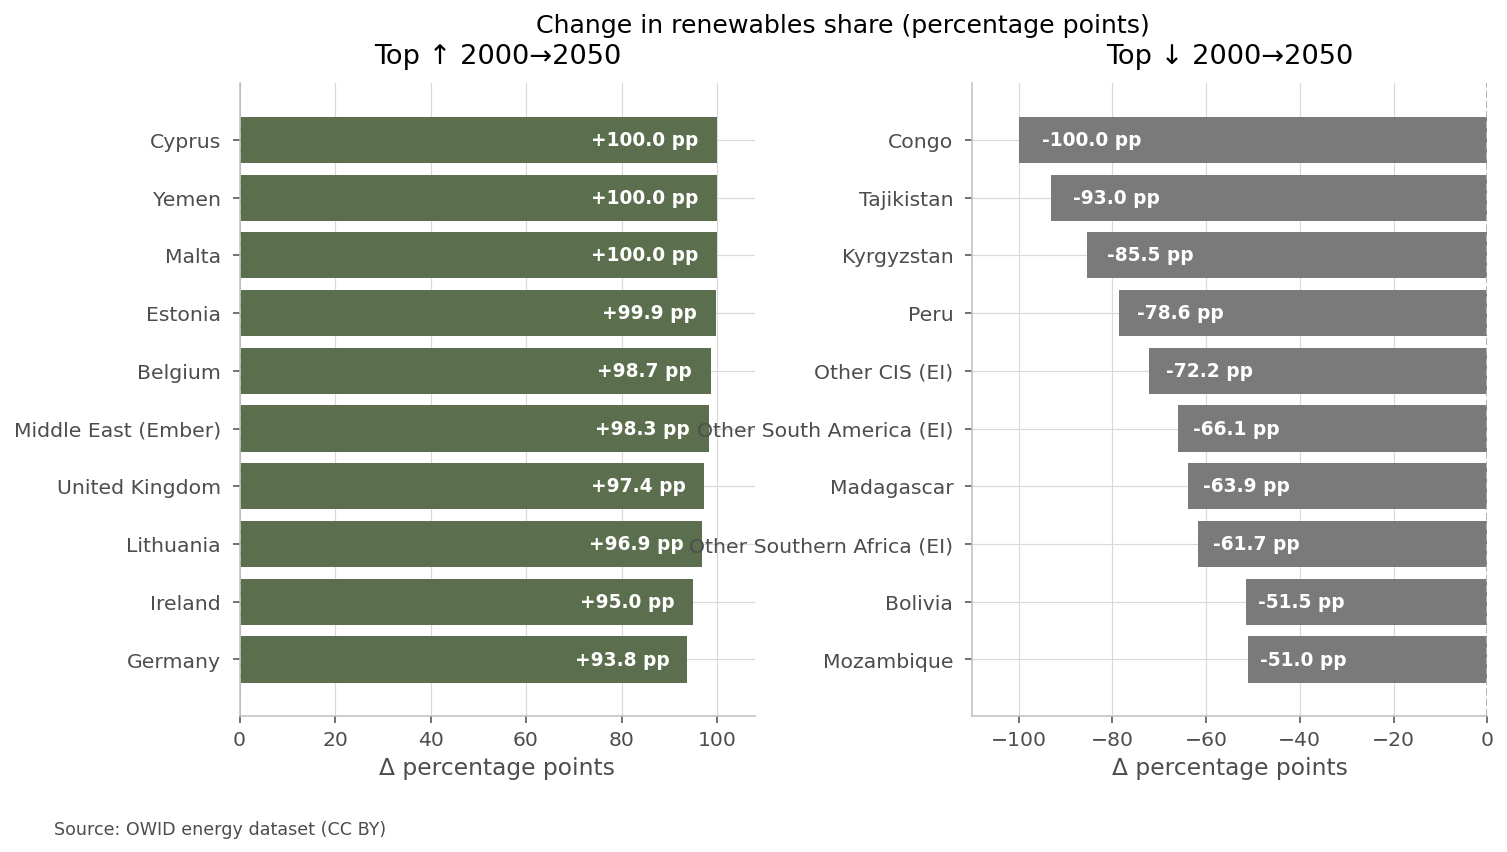

In [9]:
# horizontal bars for risers and fallers
def plot_risers_fallers(data, renew="renewables_share_elec", base_year=None, last_year=None, top_n=10, out_name="02c_table_risers_fallers_final"):
    """
    Plot side-by-side horizontal bars showing top risers and fallers in `renew`
    between `base_year` and `last_year`.

    Parameters
    - data: DataFrame with columns ["country","year", renew]
    - renew: name of the renewables share column (0..100)
    - base_year: if None, use 2000 when available else data.year.min()
    - last_year: if None, use data.year.max()
    - top_n: number of risers/fallers to show (default 10)
    - out_name: filename base for export(...)
    Returns:
    - (fig, axes, risers_df, fallers_df)
    """
    # choose sensible default years
    base_year = (2000 if (data["year"] >= 2000).any() else int(data["year"].min())) if base_year is None else int(base_year)
    last_year = int(data["year"].max()) if last_year is None else int(last_year)

    # pick rows for the two years and pivot so each country has a column per year
    TT = data.loc[data["year"].isin([base_year, last_year]), ["country", "year", renew]].dropna()
    PP = TT.pivot(index="country", columns="year", values=renew).dropna()

    # compute difference in percentage points (last - base)
    PP["dpp"] = PP[last_year] - PP[base_year]

    # top risers (largest positive dpp) and fallers (most negative dpp)
    risers  = PP.sort_values("dpp", ascending=False).head(top_n).copy()
    fallers = PP.sort_values("dpp", ascending=True ).head(top_n).copy()

    # --- plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 6.2))

    # Left: risers
    y = np.arange(len(risers))
    axes[0].barh(y, risers["dpp"], color=PALETTE["green"])
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(risers.index)
    axes[0].invert_yaxis()
    # annotate the bars with "+/- pp" labels placed inside the bars
    for i, v in enumerate(risers["dpp"]):
        pad = max(1.0, v * 0.04)
        axes[0].text(v - pad, i, f"{v:+.1f} pp", va="center", ha="right",
                     fontsize=9.6, color="white", fontweight="semibold")
    axes[0].axvline(0, color="#B3B3B3", lw=1.0, linestyle="--")
    axes[0].set_title(f"Top ↑ {base_year}→{last_year}")
    axes[0].set_xlabel("Δ percentage points")
    axes[0].margins(x=0.08, y=0.06)
    axes[0].tick_params(axis="y", pad=6)

    # Right: fallers
    y2 = np.arange(len(fallers))
    right_color = "#7A7A7A"
    axes[1].barh(y2, fallers["dpp"], color=right_color)
    axes[1].set_yticks(y2)
    axes[1].set_yticklabels(fallers.index)
    axes[1].invert_yaxis()
    # annotate fallers; labels placed inside/outside depending on sign
    for i, v in enumerate(fallers["dpp"]):
        pad = max(0.8, abs(v) * 0.05)
        axes[1].text(v + pad, i, f"{v:+.1f} pp", va="center", ha="left",
                     fontsize=9.6, color="white", fontweight="semibold")
    axes[1].axvline(0, color="#B3B3B3", lw=1.0, linestyle="--")
    axes[1].set_title(f"Top ↓ {base_year}→{last_year}")
    axes[1].set_xlabel("Δ percentage points")
    axes[1].margins(x=0.10, y=0.06)
    axes[1].tick_params(axis="y", pad=6)

    # clean up spines and overall layout
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle("Change in renewables share (percentage points)", fontsize=13, y=0.96)
    add_source(fig, "Source: OWID energy dataset (CC BY)")
    fig.subplots_adjust(wspace=0.42, bottom=0.15)

    # export and show
    export(fig, out_name)
    plt.show()

    return fig, axes, risers, fallers

# Plot risers and fallers with only historical data
fig, axes, risers_df, fallers_df = plot_risers_fallers(data=df)
fig.show()

# Plot risers and fallers with forecasted data
fig, axes, risers_df, fallers_df = plot_risers_fallers(data=data, out_name="02c_table_risers_fallers_forecasted")

Saved: figures/03_global_composition_FINAL.png


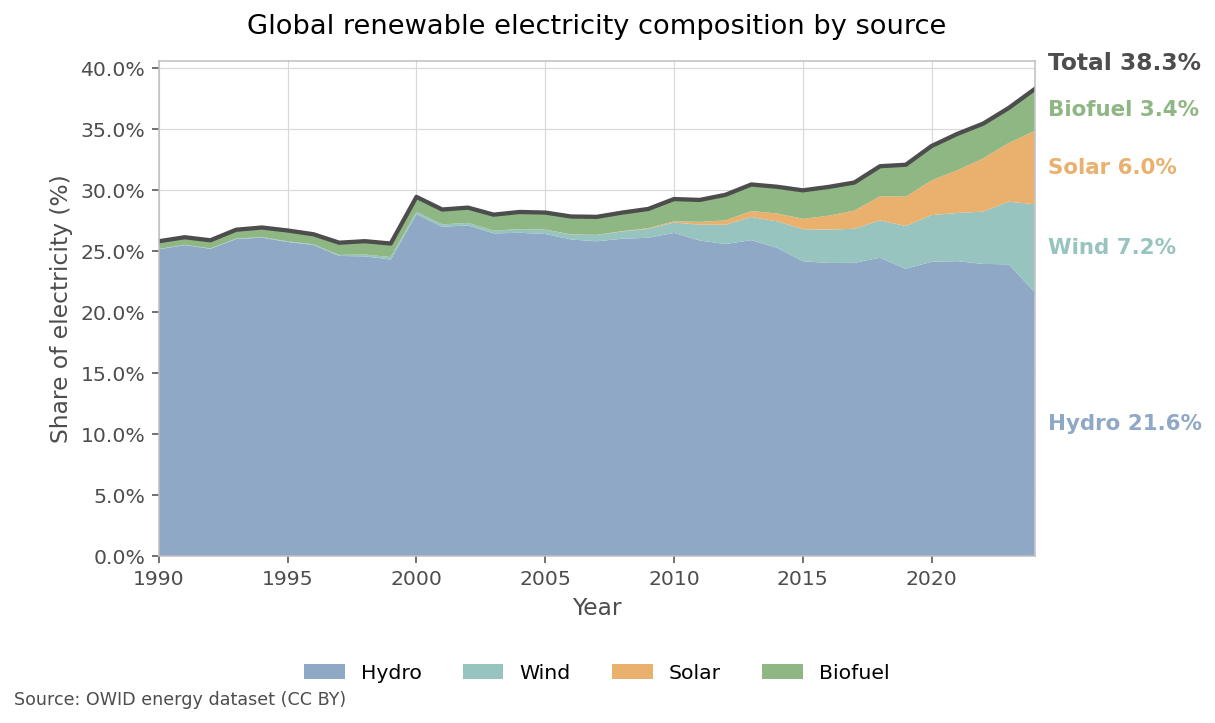

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/2083348885.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: figures/03_global_composition_forecasted.png


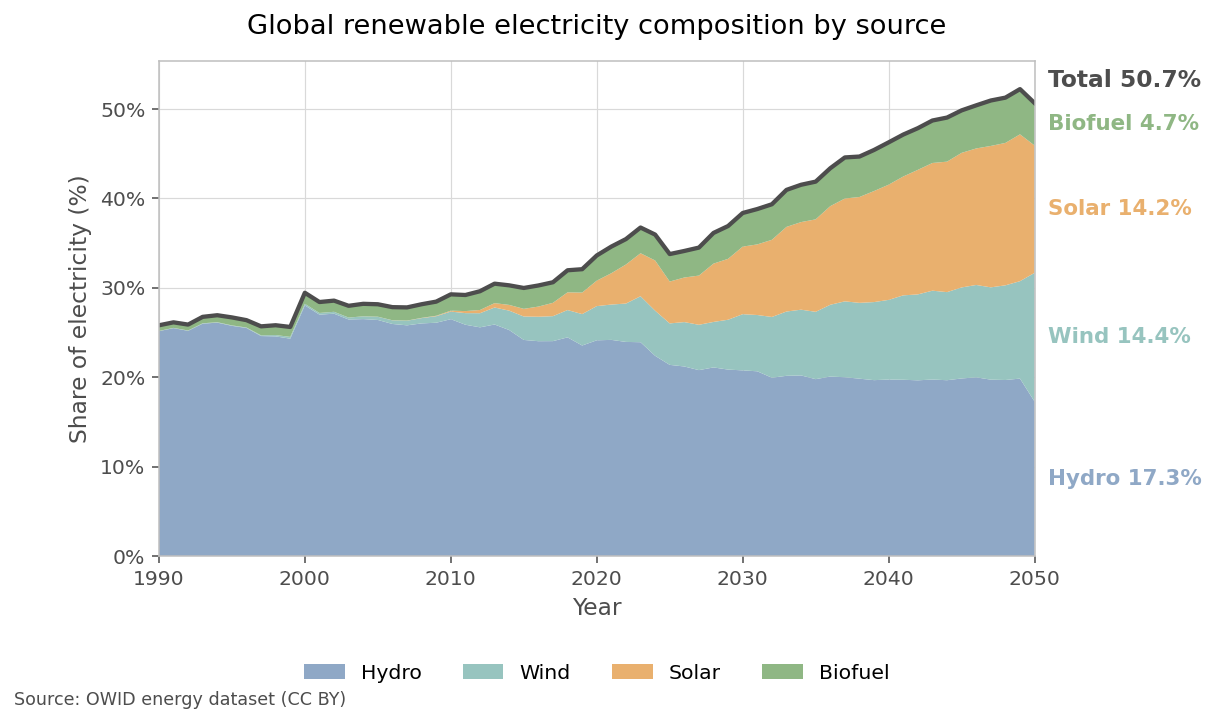

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/2083348885.py:95: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [10]:
# stacked area chart for global composition
def plot_global_composition(data=data, start_year=1990, sources=None, labels=None, colors=None, save=True, out_name="03_global_composition_FINAL"):
    """
    Plot global renewable electricity composition by source as a stacked area chart.

    Parameters
    - data: DataFrame with columns ['year', source columns...]
    - start_year: minimum year to include
    - sources: list of source column names (defaults to common component cols)
    - labels: display labels for the sources (same order as sources)
    - colors: list of colors for the stacks (same order as sources)
    - save: whether to call export(fig, out_name)
    - out_name: filename base for export(...)
    Returns:
    - (fig, ax)
    """
    # sensible defaults: pick component columns that exist in the frame
    if sources is None:
        sources = ["hydro_share_elec", "wind_share_elec", "solar_share_elec", "biofuel_share_elec"]
    sources = [c for c in sources if c in data.columns]

    # default labels and colors if not provided
    if labels is None:
        label_map = {"hydro_share_elec":"Hydro", "wind_share_elec":"Wind",
                     "solar_share_elec":"Solar", "biofuel_share_elec":"Biofuel"}
        labels = [label_map.get(c, c) for c in sources]
    if colors is None:
        colors = [STACK_COLORS.get(label, PALETTE["green_light"]) for label in labels]

    # aggregate global mean by year for the chosen sources and restrict years
    world = (
        data.loc[data["year"] >= start_year]
            .groupby("year", as_index=False)[sources]
            .mean()
            .sort_values("year")
            .fillna(0)
    )

    # prepare arrays for plotting: stacked area requires shape (n_series, n_times)
    if len(sources) == 0:
        raise ValueError("No source columns available in data for stacked area chart.")

    year = world["year"].to_numpy()
    # use DataFrame.to_numpy and transpose so vals has shape (n_series, n_times)
    vals = world[sources].to_numpy().T
    total = vals.sum(axis=0)
    cum = np.cumsum(vals, axis=0)

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(9, 5.2))
    ax.stackplot(year, vals, labels=labels, colors=colors)
    # outline total renewables as a line for readability
    ax.plot(year, total, color=PALETTE["neutral"], lw=2.2)

    ax.set_title("Global renewable electricity composition by source", pad=14)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of electricity (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    # x/y limits and layout tweaks
    x_min, x_max = year.min(), year.max()
    pad = (x_max - x_min) * 0.06
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, max(40, total.max() * 1.06))
    fig.subplots_adjust(right=0.82, top=0.9)

    # annotate the composition breakdown to the right of the plot
    x_text = x_max + pad * 0.25
    for i in range(len(sources)):
        low  = 0 if i == 0 else cum[i-1, -1]
        high = cum[i, -1]
        mid  = (low + high) / 2
        ax.text(x_text, mid, f"{labels[i]} {(high - low):.1f}%", color=colors[i],
                fontsize=11, ha="left", va="center", fontweight="semibold")

    ax.text(x_text, total[-1] + 1.2, f"Total {total[-1]:.1f}%",
            fontsize=12, ha="left", va="bottom", color=PALETTE["neutral"], fontweight="bold")

    # place legend, add source text and optionally export
    style_legend_below(fig, ax, ncol=len(labels))
    add_source(fig, "Source: OWID energy dataset (CC BY)")

    if save:
        export(fig, out_name)

    plt.show()
    return fig, ax

# Plot global composition with only historical data
fig, ax = plot_global_composition(data=df, save=True)
fig.show()

# Plot global composition with forecasted data
fig, ax = plot_global_composition(data=data, save=True, out_name="03_global_composition_forecasted")
fig.show()


Saved: figures/04_heatmap_major_countries_readable.png


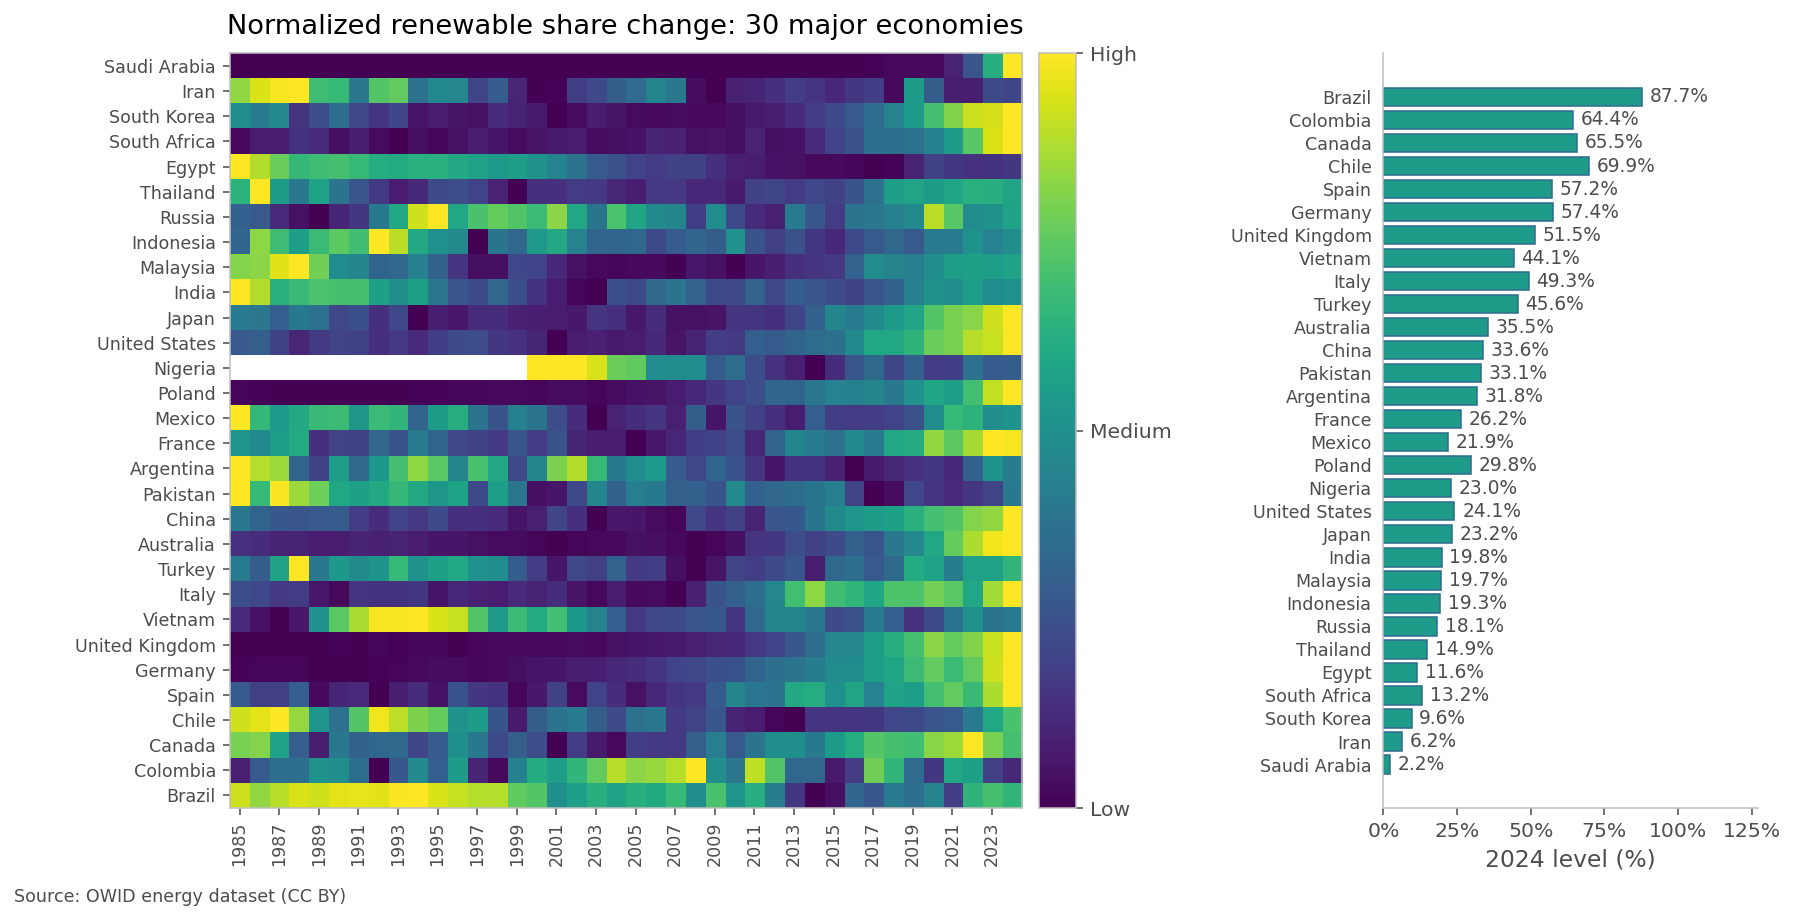

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/1018582161.py:133: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: figures/04_heatmap_major_countries_forecasted.png


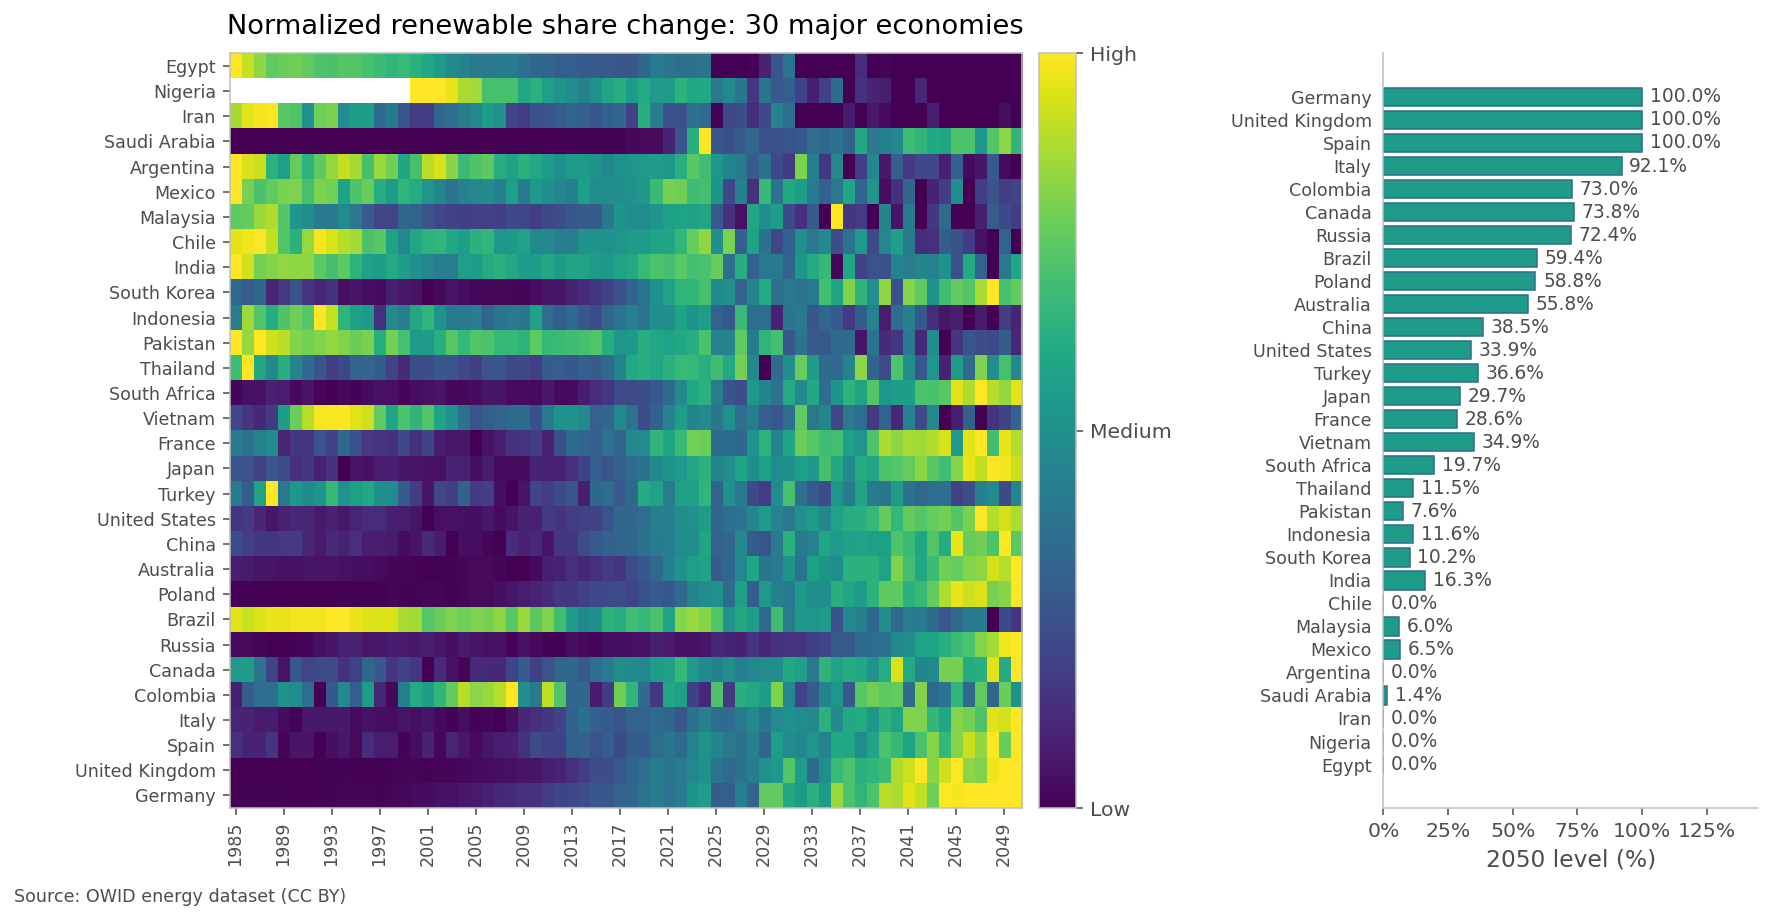

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/1018582161.py:137: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [11]:
# heatmap for major countries
def plot_heatmap_major_countries(data,
                                 renew="renewables_share_elec",
                                 major_countries=None,
                                 min_years=15,
                                 cmap_name="viridis",
                                 save=True,
                                 out_name="04_heatmap_major_countries_readable"):
    """
    Heatmap of normalized renewables-share time series for a set of major countries,
    with a right-hand panel showing the latest-year absolute values.

    Parameters
    - data: DataFrame with columns ["country","year", renew]
    - renew: column name for renewables share (0..100)
    - major_countries: list of country names to include (defaults to a 30-country list)
    - min_years: minimum number of non-NA years required per country (threshold for .dropna)
    - cmap_name: colormap for the heatmap
    - save: whether to export the figure using export(...)
    - out_name: filename base used when saving
    Returns: 
    - (fig, (ax1, ax2))
    """
    if major_countries is None:
        major_countries = [
            "United States","China","India","Brazil","Indonesia","Russia","Japan",
            "Germany","France","United Kingdom","Italy","Spain","Turkey","Mexico",
            "Canada","South Korea","Australia","South Africa","Saudi Arabia",
            "Argentina","Colombia","Chile","Poland","Egypt","Iran","Pakistan",
            "Vietnam","Thailand","Malaysia","Nigeria"
        ]

    # pivot to have years as columns, countries as rows
    P = data.pivot_table(index="country", columns="year", values=renew).dropna(how="all")
    # restrict to the requested major countries and require at least `min_years` non-NA values
    P_maj = P.loc[P.index.intersection(major_countries)].dropna(thresh=min_years, axis=0)

    if P_maj.shape[0] == 0:
        print("No major countries with sufficient coverage found.")
        return None, (None, None)

    # compute a short-window recent mean for ordering, then remove the helper column
    P_maj["mean_recent"] = P_maj.iloc[:, -5:].mean(axis=1)
    P_maj = P_maj.sort_values("mean_recent").drop(columns=["mean_recent"])

    # row-wise min and range used to normalize each country's series into [0,1]
    row_min = P_maj.min(axis=1)
    row_rng = (P_maj.max(axis=1) - row_min).replace(0, 1.0)  # avoid division by zero
    P_norm = (P_maj.sub(row_min, axis=0)).div(row_rng, axis=0)

    # absolute final-year values (for the bar plot) aligned with normalized ordering
    last_year = int(P_maj.columns.max())
    final_vals = P_maj.iloc[:, -1].reindex(P_norm.index)

    # --- plotting ---
    fig = plt.figure(figsize=(14, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[5.2, 2.3], wspace=0.50)

    # left: heatmap of normalized change
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.grid(False)
    cm = plt.colormaps
    cmap = cm.get_cmap(cmap_name)
    im = ax1.imshow(P_norm, aspect="auto", cmap=cmap, interpolation="nearest")
    ax1.set_yticks(range(len(P_norm.index)))
    ax1.set_yticklabels(P_norm.index, fontsize=9)

    # xtick spacing to avoid label crowding
    step = max(1, len(P_norm.columns) // 16)
    ax1.set_xticks(range(0, len(P_norm.columns), step))
    ax1.set_xticklabels(P_norm.columns[::step], rotation=90, fontsize=9)
    ax1.set_title("Normalized renewable share change: 30 major economies")

    cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.02)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(["Low", "Medium", "High"])

    # right: latest-year absolute levels as horizontal bars
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.grid(False)
    y = np.arange(len(final_vals))
    viridis = cm.get_cmap(cmap_name)
    bar_color = viridis(0.55)
    edge_color = viridis(0.35)

    bars = ax2.barh(
        y,
        final_vals.values,
        color=bar_color,
        edgecolor=edge_color,
        linewidth=0.8
    )

    ax2.set_yticks(y)
    ax2.set_yticklabels(final_vals.index, fontsize=9)
    ax2.tick_params(axis="y", length=0, pad=6)
    fig.subplots_adjust(left=0.12)
    ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax2.set_xlabel(f"{last_year} level (%)")

    xmax = float(final_vals.max())
    ax2.set_xlim(0, xmax * 1.45)

    # annotate bar values
    for bar in bars:
        width = bar.get_width()
        yb = bar.get_y() + bar.get_height() / 2
        ax2.text(
            width + xmax * 0.03,
            yb,
            f"{width:.1f}%",
            va="center",
            ha="left",
            fontsize=9.6,
            color=PALETTE["neutral"]
        )

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.tick_params(axis="y", pad=6)

    add_source(fig, "Source: OWID energy dataset (CC BY)")

    if save:
        export(fig, out_name)

    plt.show()
    return fig, ax1, ax2


# Plot heatmap for major countries with only historical data
fig, ax1, ax2 = plot_heatmap_major_countries(data=df, save=True)
fig.show() 

# Plot heatmap for major countries with forecasted data
fig, ax1, ax2 = plot_heatmap_major_countries(data=data, save=True, out_name="04_heatmap_major_countries_forecasted")
fig.show()


In [12]:
# world plotly choropleth for latest year
def plot_choropleth_latest(data,
                           iso_col="iso_code",
                           country_col="country",
                           renew_col="renewables_share_elec",
                           latest_year=None,
                           save=True,
                           out_html="05_choropleth_latest.html"):
    """
    Create and show a Plotly choropleth of renewables share for the latest year.

    Parameters:
    - data: DataFrame with columns including year, iso_col, country_col, renew_col
    - iso_col: column name with ISO3 codes (default "iso_code")
    - country_col: column name with full country name (default "country")
    - renew_col: renewables share column (0..100) (default "renewables_share_elec")
    - latest_year: integer year to plot; if None use data.year.max()
    - save: whether to save an interactive HTML (default True)
    - out_html: output filename for saved HTML
    Returns:
    - fig (plotly.graph_objs._figure.Figure)
    """
    # determine year to plot
    latest_year = int(data["year"].max()) if latest_year is None else int(latest_year)

    # pick rows for the selected year and keep only needed cols (drop NaNs)
    geo = (
        data.loc[data["year"] == latest_year, [iso_col, country_col, renew_col]]
            .dropna()
            .rename(columns={iso_col: "iso_code", country_col: "country_name", renew_col: "renew_share"})
    )

    # build choropleth
    fig = px.choropleth(
        geo,
        locations="iso_code",
        color="renew_share",
        hover_name="country_name",
        color_continuous_scale=px.colors.sequential.Viridis,
        range_color=(0, 100),
        title=f"Renewables share of electricity — {latest_year}",
    )

    # nicer hover, colorbar and map appearance
    fig.update_traces(hovertemplate="<b>%{hovertext}</b><br>Share: %{z:.1f}%<extra></extra>")

    fig.update_coloraxes(
        cmin=0, cmax=100,
        colorbar=dict(
            title="%",
            ticks="outside",
            ticklen=4,
            tickcolor="#999",
            outlinewidth=0,
        )
    )

    fig.update_geos(
        showcountries=True, countrycolor="#FFFFFF", countrywidth=0.5,
        showcoastlines=False, showframe=False, showsubunits=False,
        showland=True, landcolor="#F3F5EE",
        showocean=True, oceancolor="#E8EEF6",
        projection_type="natural earth", fitbounds="locations"
    )

    fig.update_layout(
        font=dict(family="DejaVu Sans", size=12, color="#4D4D4D"),
        margin=dict(l=10, r=10, t=60, b=10),
        title=dict(y=0.93, x=0.5, xanchor="center", font=dict(size=18)),
    )

    # show and optionally save interactive HTML
    fig.show()
    if save:
        fig.write_html(out_html, include_plotlyjs="cdn")
    return fig

# Plot choropleth with only historical data
fig = plot_choropleth_latest(data=df, save=True)

# Plot choropleth with forecasted data
fig = plot_choropleth_latest(data=data, save=True, out_html="05_choropleth_latest_forecasted.html")

print("Html choropleth generated.")

Html choropleth generated.


Saved: figures/06_scatter_gdp_vs_renew_final.png


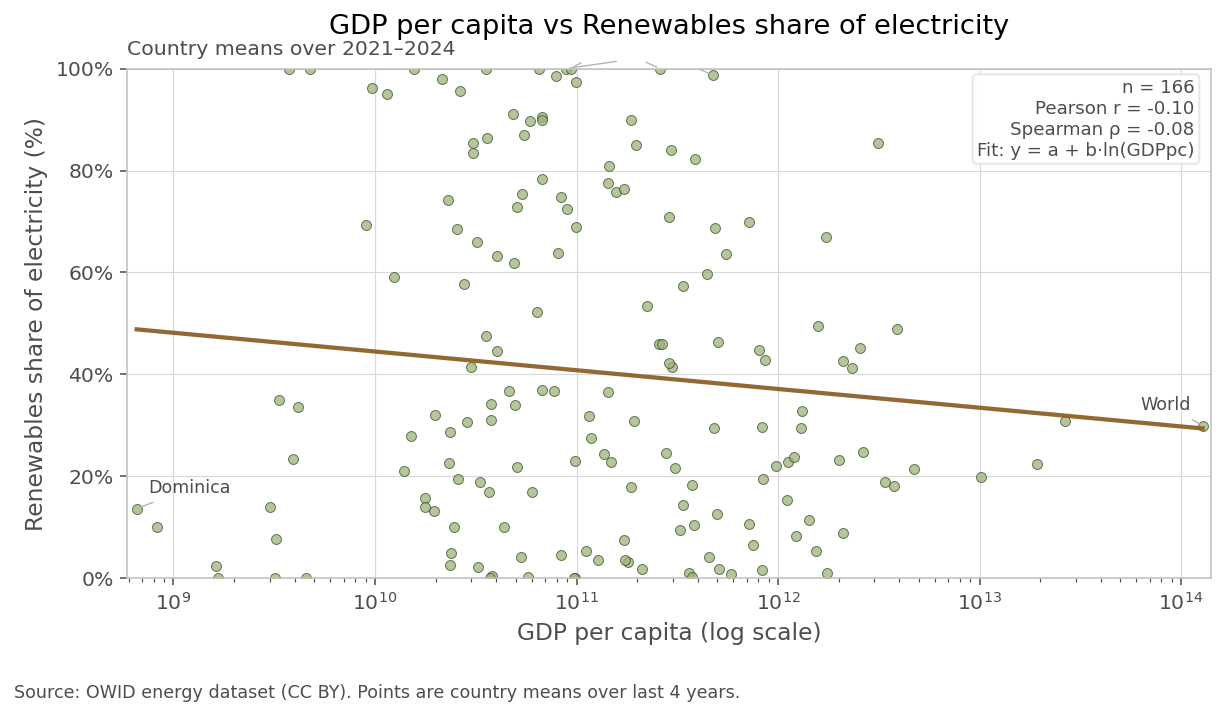

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/3630390638.py:108: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/3630390638.py:26: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



Saved: figures/06_scatter_gdp_vs_renew_forecasted.png


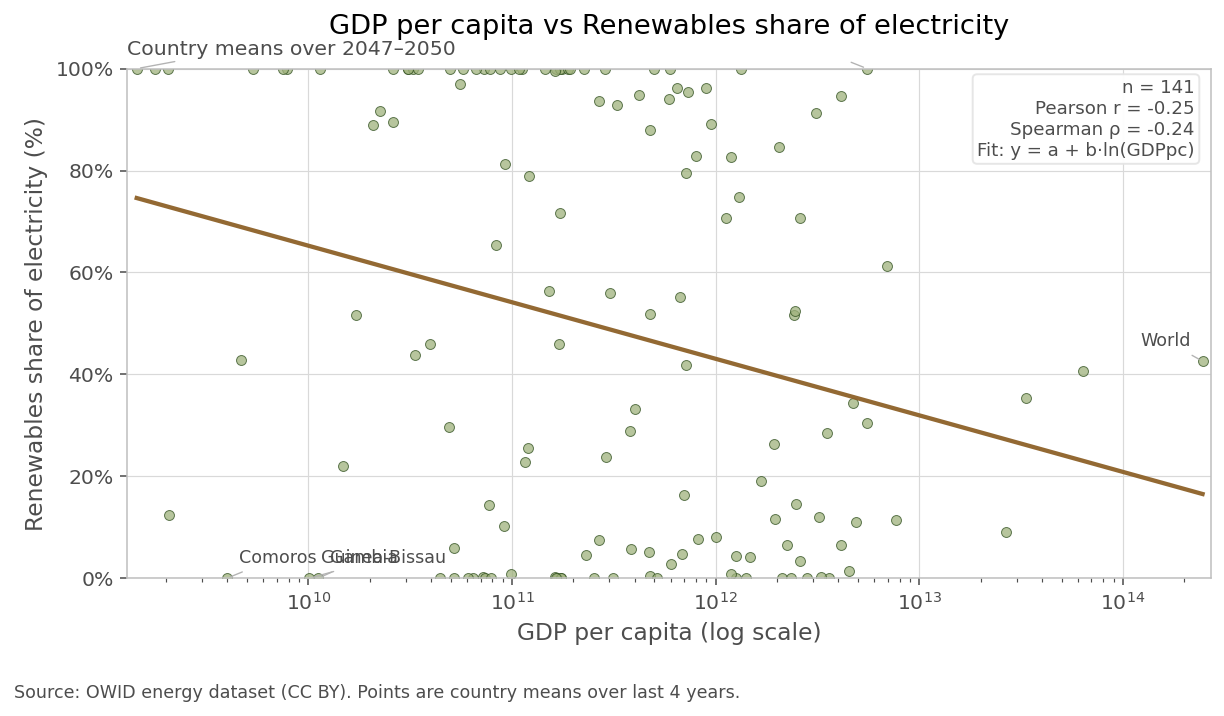

/var/folders/bf/gncyklj116jds6n2thdpny0c0000gn/T/ipykernel_79508/3630390638.py:112: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [13]:
# scatter plot GDP per capita vs renewables share
def plot_gdp_vs_renewables(
    data,
    renew: str = "renewables_share_elec",
    years_window: int = 4,
    save: bool = True,
    out_name: str = "06_scatter_gdp_vs_renew_final",
):
    """
    Scatter plot of country mean renewables share vs GDP per capita (log-x).
    - Aggregates country means over the last `years_window` years.
    - Fits a linear model on ln(GDPpc) -> renew and plots the fit.
    - Computes Pearson and Spearman correlation (on ln(GDPpc)).
    - save: whether to call export(fig, out_name) (must be provided as parameter).
    Returns: 
    - fig, ax: the figure and axis objects
    - pearson_r: pearson correlation coefficient
    - spearman_r: spearman correlation coefficient
    """
    latest_year = int(data["year"].max())

    # country means over recent window
    S = (
        data.loc[data["year"] >= latest_year - (years_window - 1)]
            .groupby("country", as_index=False)
            .mean(numeric_only=True)
    )
    
    # numeric arrays and mask valid positive GDP
    X = pd.to_numeric(S["gdp"], errors="coerce").to_numpy()
    Y = pd.to_numeric(S[renew], errors="coerce").to_numpy()
    mask = np.isfinite(X) & np.isfinite(Y) & (X > 0)
    x = X[mask].astype(float)
    y = Y[mask].astype(float)

    if x.size < 3:
        raise ValueError("Not enough countries with valid GDPpc and renewables to plot")

    # if renew is 0..1 convert to percent
    if np.nanmax(y) <= 1.5:
        y = y * 100

    # fit linear model on ln(GDPpc)
    lx = np.log(x)
    m, b = np.polyfit(lx, y, 1)
    xg = np.geomspace(x.min(), x.max(), 200)
    yg = b + m * np.log(xg)

    # correlations (use first element for compatibility)
    rp = float(pearsonr(lx, y)[0])
    rs = float(spearmanr(lx, y)[0])

    # prepare annotation table for a few interesting points (largest residuals + extremes)
    res = y - (b + m * lx)
    S2 = S.loc[mask, ["country"]].copy().reset_index(drop=True)
    S2["x"], S2["y"], S2["res"] = x, y, res
    ix = np.argsort(np.abs(res))[-4:]
    extra = [np.argmin(x), np.argmax(x)]
    pick_idx = list(dict.fromkeys(list(ix) + extra))

    # plotting
    fig, ax = plt.subplots()
    ax.scatter(x, y, s=26, alpha=0.75, color=PALETTE["green_light"], edgecolors=PALETTE["green_dark"], linewidths=0.5, zorder=2)
    ax.plot(xg, yg, color=PALETTE["orange_dark"], lw=2.2, alpha=0.95, zorder=3)

    ax.set_xscale("log")
    ax.set_xlim(x.min() * 0.9, x.max() * 1.1)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.set_xlabel("GDP per capita (log scale)")
    ax.set_ylabel("Renewables share of electricity (%)")
    window = f"{int(latest_year - (years_window - 1))}–{latest_year}"
    ax.set_title("GDP per capita vs Renewables share of electricity")
    ax.text(0.0, 1.02, f"Country means over {window}", transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color=PALETTE["neutral"])

    # annotate selected countries
    for _, r0 in S2.iloc[pick_idx].iterrows():
        ha = "left" if r0["x"] < np.median(x) else "right"
        offs = (6, 6) if ha == "left" else (-6, 6)
        ax.annotate(
            r0["country"], (r0["x"], r0["y"]),
            xytext=offs, textcoords="offset points",
            fontsize=9.0, color=PALETTE["neutral"],
            ha=ha, va="bottom",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="#B3B3B3"),
            clip_on=True
        )

    ax.text(0.985, 0.98,
            f"n = {len(x)}\nPearson r = {rp:.2f}\nSpearman ρ = {rs:.2f}\nFit: y = a + b·ln(GDPpc)",
            transform=ax.transAxes, ha="right", va="top", fontsize=9.4, color=PALETTE["neutral"],
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#E5E5E5", alpha=0.96))

    add_source(fig, f"Source: OWID energy dataset (CC BY). Points are country means over last {years_window} years.")
    plt.subplots_adjust(bottom=0.16, top=0.86, right=0.96)

    if save:
        export(fig, out_name)

    plt.subplots_adjust(top=0.88, bottom=0.18, left=0.10, right=0.96)
    ax.set_title("GDP per capita vs Renewables share of electricity", pad=18)
    plt.show()

    return fig, ax, rp, rs

# Plot GDP vs renewables with only historical data
fig, ax, pearson_r, spearman_r = plot_gdp_vs_renewables(data=df, save=True)
fig.show()

# Plot GDP vs renewables with forecasted data
fig, ax, pearson_r, spearman_r = plot_gdp_vs_renewables(data=data, save=True, out_name="06_scatter_gdp_vs_renew_forecasted")
fig.show()


Saved: figures/07_hist_socio_mix_clusters_2022.png


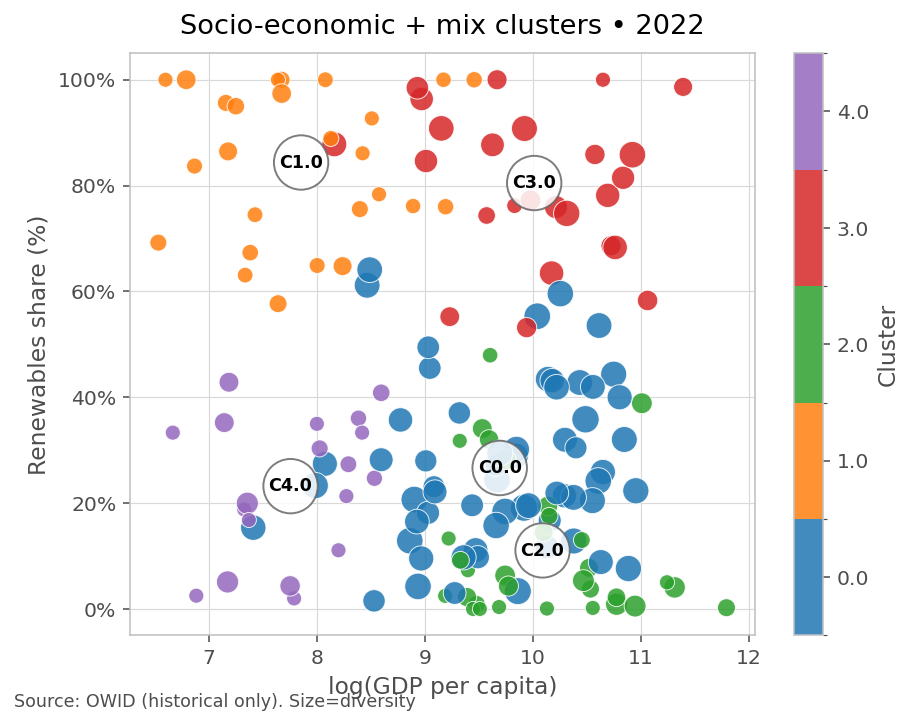

Saved: figures/08_hist_source_mix_centroids_2024.png


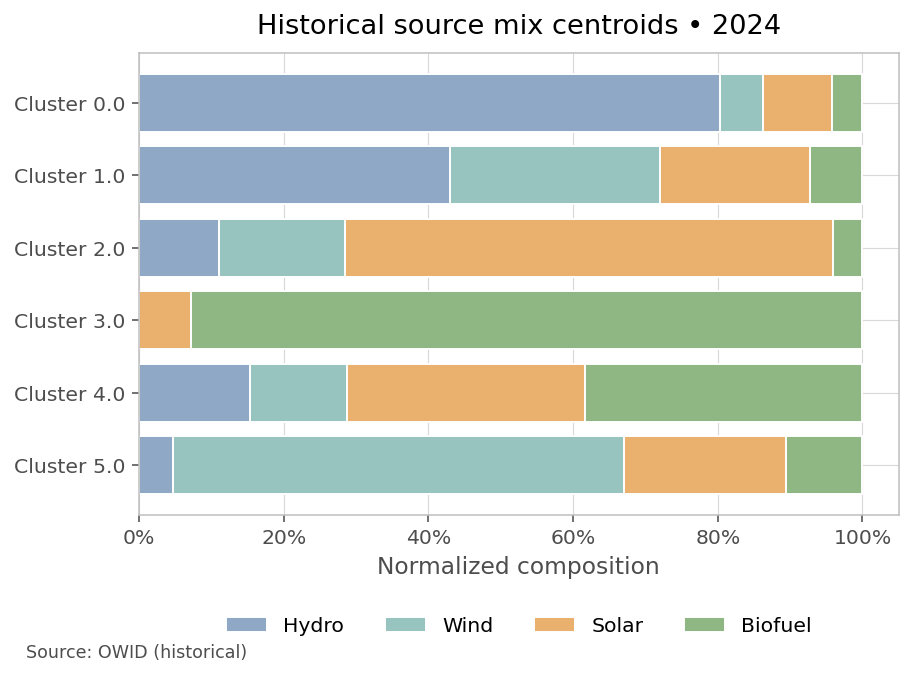

Saved: figures/09_hist_velocity_clusters_2024.png


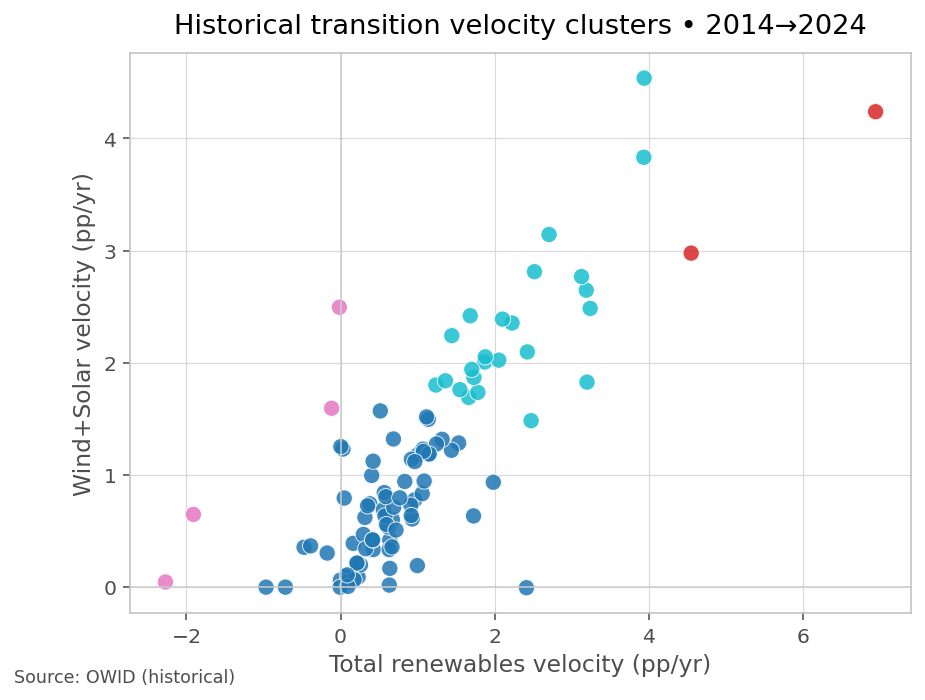

Saved: 07b_choropleth_socio_mix_2022.html
Saved: figures/cluster_snapshot_historical_latest.csv
Socio k=5 score=0.364; Source k=6; Velocity k=4


In [14]:
# --- HISTORICAL-ONLY CLUSTERING (no forecast data) ---

# Preserve historical dataset before forecasting (if not already saved)
if 'data_hist' not in globals():
    try:
        data_hist = countries[[c for c in [
            "country","year","iso_code","gdp_per_capita",
            "renewables_share_elec","hydro_share_elec","wind_share_elec",
            "solar_share_elec","biofuel_share_elec","gdp","population"
        ] if c in countries.columns]].copy()
        data_hist = ensure_gdp_per_capita(data_hist, df_full)
    except Exception:
        # fallback: rebuild minimal historical frame from df_full
        data_hist = df_full[df_full["iso_code"].astype(str).str.len()==3][[
            c for c in ["country","year","iso_code","gdp_per_capita",
                        "renewables_share_elec","hydro_share_elec","wind_share_elec",
                        "solar_share_elec","biofuel_share_elec","gdp","population"]
            if c in df_full.columns
        ]].copy()
        try:
            data_hist = ensure_gdp_per_capita(data_hist, df_full)
        except Exception:
            pass

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def _shannon_entropy(comp_values):
    comps = np.array(comp_values, dtype=float)
    s = comps.sum()
    if s <= 0: return np.nan
    p = comps / s
    p = p[p > 0]
    if p.size == 0: return np.nan
    return -np.sum(p * np.log(p)) / np.log(len(comp_values))

# 1. Joint socio-economic + mix clustering (latest real year)
def joint_socio_mix_clusters(df, k_range=range(3,8), random_state=42):
    comps = [c for c in ['hydro_share_elec','wind_share_elec','solar_share_elec','biofuel_share_elec'] if c in df.columns]
    if len(comps) < 2: return df.assign(socio_mix_cluster=np.nan, diversity=np.nan)
    # latest year with GDP
    yr_valid = df.groupby('year')['gdp_per_capita'].apply(lambda s: s.notna().sum()>0)
    if not yr_valid.any(): return df.assign(socio_mix_cluster=np.nan, diversity=np.nan)
    year = int(yr_valid[yr_valid].index.max())
    latest = df[df['year']==year].dropna(subset=['renewables_share_elec','gdp_per_capita'])
    if latest.empty: return df.assign(socio_mix_cluster=np.nan, diversity=np.nan)
    latest['diversity'] = latest[comps].apply(_shannon_entropy, axis=1)
    latest = latest.dropna(subset=['diversity'])
    if latest.empty: return df.assign(socio_mix_cluster=np.nan, diversity=np.nan)
    feats = latest[['renewables_share_elec','gdp_per_capita','diversity']].copy()
    feats['log_gdp_pc'] = np.log(feats['gdp_per_capita'].clip(lower=1))
    X = feats[['renewables_share_elec','log_gdp_pc','diversity']].to_numpy()
    Z = StandardScaler().fit_transform(X)
    best_k,best_score,best_labels = None,-1,None
    for k in k_range:
        if k >= len(Z): break
        km = KMeans(n_clusters=k, n_init=30, random_state=random_state)
        labels = km.fit_predict(Z)
        score = silhouette_score(Z, labels)
        if score > best_score: best_k,best_score,best_labels = k,score,labels
    latest['socio_mix_cluster'] = best_labels
    out = df.merge(latest[['country','socio_mix_cluster','diversity']], on='country', how='left')
    return out, year, best_k, best_score

def plot_socio_mix(df_with, year):
    D = df_with[df_with['year']==year].dropna(subset=['socio_mix_cluster','renewables_share_elec','gdp_per_capita','diversity'])
    if D.empty: 
        print("No socio mix data."); return
    # discrete colormap + boundaries
    import matplotlib as mpl
    clusters = sorted(D['socio_mix_cluster'].unique())
    ncl = len(clusters)
    cmap = mpl.colors.ListedColormap(plt.get_cmap('tab10').colors[:ncl])
    boundaries = np.arange(-0.5, ncl + 0.5, 1)
    norm = mpl.colors.BoundaryNorm(boundaries, ncl)
    fig, ax = plt.subplots(figsize=(7.2,5.4))
    sc = ax.scatter(np.log(D['gdp_per_capita']), D['renewables_share_elec'],
                    c=D['socio_mix_cluster'], s=60+140*D['diversity'],
                    cmap=cmap, norm=norm, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_xlabel('log(GDP per capita)'); ax.set_ylabel('Renewables share (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.set_title(f'Socio-economic + mix clusters • {year}')
    for cl in clusters:
        sub = D[D['socio_mix_cluster']==cl]
        ax.text(np.log(sub['gdp_per_capita']).mean(), sub['renewables_share_elec'].mean(),
                f'C{cl}', ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='circle', fc='white', ec='#666', alpha=0.85))
    cbar = fig.colorbar(sc, ax=ax, boundaries=boundaries)
    cbar.set_label('Cluster')
    cbar.set_ticks(clusters)
    cbar.set_ticklabels([str(c) for c in clusters])
    add_source(fig,'Source: OWID (historical only). Size=diversity')
    export(fig, f'07_hist_socio_mix_clusters_{year}')
    plt.show()

# 2. Latest-year normalized source mix clustering (silhouette k)
def source_mix_clusters(df, k_range=range(3,8), random_state=42):
    comps = [c for c in ['hydro_share_elec','wind_share_elec','solar_share_elec','biofuel_share_elec'] if c in df.columns]
    year = int(df['year'].max())
    Xraw = df[df['year']==year][['country']+comps].dropna()
    if Xraw.empty or len(comps)<2: return df.assign(source_mix_cluster=np.nan), year, np.nan
    X = Xraw[comps].to_numpy(float)
    sums = X.sum(axis=1, keepdims=True); sums[sums==0]=1
    X = X / sums
    Z = StandardScaler().fit_transform(X)
    best_k,best_score,best_labels = None,-1,None
    for k in k_range:
        if k >= len(Z): break
        km = KMeans(n_clusters=k, n_init=40, random_state=random_state)
        labels = km.fit_predict(Z)
        score = silhouette_score(Z, labels)
        if score > best_score: best_k,best_score,best_labels = k,score,labels
    lab = Xraw[['country']].copy()
    lab['source_mix_cluster']=best_labels; lab['source_mix_k']=best_k
    out = df.merge(lab, on='country', how='left')
    return out, year, best_k

def plot_source_mix_centroids(df_with, year):
    comps = [c for c in ['hydro_share_elec','wind_share_elec','solar_share_elec','biofuel_share_elec'] if c in df_with.columns]
    D = df_with[df_with['year']==year].dropna(subset=['source_mix_cluster'])
    if D.empty: print("No source mix data."); return
    M = D[['source_mix_cluster']+comps].copy()
    M[comps] = M[comps].div(M[comps].sum(axis=1), axis=0).fillna(0)
    C = M.groupby('source_mix_cluster')[comps].mean()
    fig, ax = plt.subplots(figsize=(7,5))
    y = np.arange(len(C)); left = np.zeros(len(C))
    label_map={'hydro_share_elec':'Hydro','wind_share_elec':'Wind','solar_share_elec':'Solar','biofuel_share_elec':'Biofuel'}
    for c in comps:
        vals = C[c].values
        ax.barh(y, vals, left=left, label=label_map[c], color=STACK_COLORS.get(label_map[c],'#BFBFBF'), edgecolor='white')
        left += vals
    ax.set_yticks(y); ax.set_yticklabels([f'Cluster {i}' for i in C.index]); ax.invert_yaxis()
    ax.set_xlabel('Normalized composition'); ax.set_title(f'Historical source mix centroids • {year}')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    style_legend_below(fig, ax, ncol=len(comps))
    add_source(fig,'Source: OWID (historical)'); export(fig, f'08_hist_source_mix_centroids_{year}')
    plt.show()

# 3. Transition velocity clusters (historical window)
def velocity_clusters_hist(df, span_years=10, k_range=range(3,7), random_state=42):
    last_year = int(df['year'].max())
    base_year = max(int(df['year'].min()), last_year - span_years)
    comps_all = ['renewables_share_elec','hydro_share_elec','wind_share_elec','solar_share_elec','biofuel_share_elec']
    comps = [c for c in comps_all if c in df.columns]
    A = df[df['year'].isin([base_year,last_year])][['country','year']+comps].dropna()
    P = A.pivot(index='country', columns='year', values=comps).dropna()
    if P.empty: return df.assign(velocity_cluster=np.nan), None
    rows=[]
    for ctry in P.index:
        feat={'country':ctry}
        for c in comps:
            feat[f'vel_{c}'] = (P.loc[ctry,(c,last_year)] - P.loc[ctry,(c,base_year)]) / (last_year-base_year if last_year>base_year else 1)
        rows.append(feat)
    F = pd.DataFrame(rows).dropna()
    Z = StandardScaler().fit_transform(F.drop(columns=['country']).to_numpy())
    best_k,best_score,best_labels = None,-1,None
    for k in k_range:
        if k >= len(Z): break
        km = KMeans(n_clusters=k, n_init=40, random_state=random_state)
        labels = km.fit_predict(Z)
        score = silhouette_score(Z, labels)
        if score > best_score: best_k,best_score,best_labels = k,score,labels
    F['velocity_cluster']=best_labels; F['base_year']=base_year; F['last_year']=last_year
    out = df.merge(F[['country','velocity_cluster']], on='country', how='left')
    return out, F

def plot_velocity_hist(F):
    if F is None or F.empty: print("No velocity data."); return
    fig, ax = plt.subplots(figsize=(7.2,5.2))
    v_tot = F['vel_renewables_share_elec']
    v_wind = F.get('vel_wind_share_elec', pd.Series(0,index=F.index))
    v_solar = F.get('vel_solar_share_elec', pd.Series(0,index=F.index))
    ax.scatter(v_tot, v_wind+v_solar, c=F['velocity_cluster'], cmap='tab10', edgecolor='white', linewidth=0.5, s=70, alpha=0.85)
    ax.axhline(0,color='#ccc',lw=0.8); ax.axvline(0,color='#ccc',lw=0.8)
    ax.set_xlabel('Total renewables velocity (pp/yr)')
    ax.set_ylabel('Wind+Solar velocity (pp/yr)')
    ax.set_title(f'Historical transition velocity clusters • {F["base_year"].iloc[0]}→{F["last_year"].iloc[0]}')
    add_source(fig,'Source: OWID (historical)'); export(fig, f'09_hist_velocity_clusters_{F["last_year"].iloc[0]}')
    plt.show()

# Run on historical only
hist_socio, socio_year, socio_k, socio_score = joint_socio_mix_clusters(data_hist)
plot_socio_mix(hist_socio, socio_year)

hist_source, source_year, source_k = source_mix_clusters(data_hist)
plot_source_mix_centroids(hist_source, source_year)

hist_velocity, velocity_features_hist = velocity_clusters_hist(data_hist, span_years=10)
plot_velocity_hist(velocity_features_hist)

def plot_choropleth_socio_mix(hist_df, year, iso_col="iso_code", cluster_col="socio_mix_cluster",
                              renew_col="renewables_share_elec", gdp_col="gdp_per_capita",
                              save=True, out_html=None):
    """
    Choropleth world map of socio-economic + mix clusters for the given historical year.
    """
    import plotly.express as px
    if out_html is None:
        out_html = f"07b_choropleth_socio_mix_{year}.html"

    df_year = hist_df.loc[hist_df["year"] == year].dropna(subset=[cluster_col, iso_col])
    if df_year.empty:
        print("No data for socio mix choropleth.")
        return None

    # ensure integer clusters -> string labels for discrete coloring
    df_year["_cluster_str"] = df_year[cluster_col].astype(int).astype(str)

    # build discrete color map
    cmap = plt.get_cmap("tab10")
    uniq = sorted(df_year[cluster_col].astype(int).unique())
    color_map = {str(c): f"rgba({int(r*255)},{int(g*255)},{int(b*255)},0.95)"
                 for c,(r,g,b,_) in zip(uniq, [cmap(i) for i in range(len(uniq))])}

    hover_cols = []
    if renew_col in df_year.columns: hover_cols.append(renew_col)
    if gdp_col in df_year.columns: hover_cols.append(gdp_col)

    fig = px.choropleth(
        df_year,
        locations=iso_col,
        color="_cluster_str",
        hover_name="country",
        hover_data=hover_cols,
        title=f"Socio-economic + mix clusters • {year}",
        color_discrete_map=color_map
    )

    fig.update_traces(
        hovertemplate="<b>%{hovertext}</b><br>Cluster: %{customdata[0]}<br>" +
                      ("Renewables: %{customdata[1]:.1f}%<br>" if renew_col in hover_cols else "") +
                      ("GDP pc: %{customdata[2]:,.0f}<br>" if gdp_col in hover_cols else "") +
                      "<extra></extra>"
    )

    fig.update_geos(
        showcountries=True, countrycolor="#FFFFFF", countrywidth=0.4,
        showcoastlines=False, showframe=False, showsubunits=False,
        showland=True, landcolor="#F3F5EE", showocean=True, oceancolor="#E8EEF6",
        projection_type="natural earth", fitbounds="locations"
    )
    fig.update_layout(
        margin=dict(l=10, r=10, t=60, b=10),
        legend_title_text="Cluster",
        font=dict(family="DejaVu Sans", size=12, color="#4D4D4D")
    )
    fig.show()
    if save:
        fig.write_html(out_html, include_plotlyjs="cdn")
        print(f"Saved: {out_html}")
    return fig

# After computing hist_socio and socio_year:
try:
    plot_choropleth_socio_mix(hist_socio, socio_year, save=True)
except Exception as e:
    print("Socio mix choropleth failed:", e)

# Consolidated historical cluster snapshot
latest_hist_year = int(data_hist['year'].max())
cluster_hist = data_hist.merge(
    hist_socio[['country','socio_mix_cluster','diversity']].drop_duplicates(), on='country', how='left'
).merge(
    hist_source[['country','source_mix_cluster','source_mix_k']].drop_duplicates(), on='country', how='left'
).merge(
    hist_velocity[['country','velocity_cluster']].drop_duplicates(), on='country', how='left'
)

snapshot_hist = cluster_hist[cluster_hist['year']==latest_hist_year][[
    'country','socio_mix_cluster','diversity','source_mix_cluster','source_mix_k',
    'velocity_cluster','renewables_share_elec','gdp_per_capita'
]].drop_duplicates().sort_values('renewables_share_elec', ascending=False)

snapshot_hist.to_csv('figures/cluster_snapshot_historical_latest.csv', index=False)
print("Saved: figures/cluster_snapshot_historical_latest.csv")
print(f"Socio k={socio_k} score={socio_score:.3f}; Source k={source_k}; Velocity k={velocity_features_hist['velocity_cluster'].nunique() if velocity_features_hist is not None else 'NA'}")
